In [1]:
import os
import pandas as pd
import numpy as np
import boto3
from tqdm import tqdm
import datetime as dt
import pickle
import warnings
# Suppress PerformanceWarning
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

try:
    import catboost as cb
except:
    ! pip install catboost

In [2]:
print(f'Last run date: {dt.datetime.today()}')

Last run date: 2024-05-08 16:58:37.877453


### Functions

In [3]:
# download from s3
def download_from_s3(str_local_path, str_bucket_path, str_project):
    # init client
    cls_client = boto3.client(
        's3',
    )
    # download file
    cls_client.download_file(
        str_project, 
        str_bucket_path, 
        str_local_path,
    )

In [4]:
# get tier
def get_tier(flt_ecnl, dict_tiers):
    if flt_ecnl <= dict_tiers['A1']:
        return 'A1'
    elif flt_ecnl <= dict_tiers['A']:
        return 'A'
    elif flt_ecnl <= dict_tiers['B']:
        return 'B'
    elif flt_ecnl <= dict_tiers['C']:
        return 'C'
    elif flt_ecnl <= dict_tiers['D']:
        return 'D'
    else:
        return 'Decline'

In [5]:
def plot_distributions_by_bktype(df_grouped, str_col):
    list_str_bktype = [
        '7.0',
        '13.0',
        'nan',
    ]
    int_nrows = df_grouped.shape[0]
    str_title = f"""
    Distributions of {str_col} by BK Type (N = {int_nrows})
    """
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title(str_title)
    ax.set_xlabel(str_col)
    for str_bktype in list_str_bktype:
        df_tmp = df_grouped[df_grouped['intopenbktype__app'] == str_bktype].copy()
        list_values = list(df_tmp[str_col])
        flt_mdn = np.median(list_values)
        flt_mean = np.mean(list_values)
        flt_sd = np.std(list_values)
        str_label = f'{str_bktype} - Mdn = {flt_mdn:0.4f}; Mn = {flt_mean:0.4f} (+/- SD = {flt_sd:0.4f})'
        sns.kdeplot(list_values, label=str_label)
    plt.legend()
    plt.show()

In [6]:
def plot_distributions_by_dealertype(df_grouped, str_col):
    list_str_dealertype = [
        'franchise',
        'independent',
        'referral',
    ]
    int_nrows = df_grouped.shape[0]
    str_title = f"""
    Distributions of {str_col} by Dealer Type (N = {int_nrows})
    """
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title(str_title)
    ax.set_xlabel(str_col)
    for str_dealertype in list_str_dealertype:
        df_tmp = df_grouped[df_grouped['strdealershiptrackertype__app'] == str_dealertype].copy()
        list_values = list(df_tmp[str_col])
        flt_mdn = np.median(list_values)
        flt_mean = np.mean(list_values)
        flt_sd = np.std(list_values)
        str_label = f'{str_dealertype} - Mdn = {flt_mdn:0.4f}; Mn = {flt_mean:0.4f} (+/- SD = {flt_sd:0.4f})'
        sns.kdeplot(list_values, label=str_label)
    plt.legend()
    plt.show()

In [7]:
def correlation_with_ltv(df_grouped, str_col):
    x = df_grouped['ENG-loan_to_value']
    y = df_grouped[str_col]
    flt_coef, flt_p = pearsonr(x, y)
    str_title = f"""
    {str_col} by Loan to Value
    r = {flt_coef:0.4f}; p = {flt_p:0.4f}
    """
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.set_title(str_title)
    ax.set_xlabel('Loan to Value')
    ax.set_ylabel(str_col)
    ax.scatter(x, y, alpha=0.2)
    plt.show()

In [8]:
def correlation_with_income(df_grouped, str_col):
    x = df_grouped['fltgrossmonthly__income_sum']
    y = df_grouped[str_col]
    flt_coef, flt_p = pearsonr(x, y)
    str_title = f"""
    {str_col} by Income
    r = {flt_coef:0.4f}; p = {flt_p:0.4f}
    """
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.set_title(str_title)
    ax.set_xlabel('Income')
    ax.set_ylabel(str_col)
    ax.scatter(x, y, alpha=0.2)
    plt.show()

In [9]:
def mean_ltv_by_quantile(df_grouped, str_col):
    df_tmp = df_grouped.copy()
    df_tmp['quantile'] = pd.qcut(df_tmp[str_col], 20, labels=False)
    df_tmp = df_tmp.groupby('quantile', as_index=False).agg({
        'ENG-loan_to_value': 'mean',
    })
    str_title = f"""
    Mean LTV by {str_col} Quantile
    """
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title(str_title)
    ax.set_xlabel(f'Quantile of {str_col}')
    ax.set_ylabel('Mean LTV')
    ax.plot(df_tmp['quantile'].astype(str), df_tmp['ENG-loan_to_value'])
    plt.show()

In [10]:
def mean_income_by_quantile(df_grouped, str_col):
    df_tmp = df_grouped.copy()
    df_tmp['quantile'] = pd.qcut(df_tmp[str_col], 20, labels=False)
    df_tmp = df_tmp.groupby('quantile', as_index=False).agg({
        'fltgrossmonthly__income_sum': 'mean',
    })
    str_title = f"""
    Mean Income by {str_col} Quantile
    """
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title(str_title)
    ax.set_xlabel(f'Quantile of {str_col}')
    ax.set_ylabel('Mean Income')
    ax.plot(df_tmp['quantile'].astype(str), df_tmp['fltgrossmonthly__income_sum'])
    plt.show()

### Constants

In [11]:
# project
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')
# task
str_task = os.getcwd().split('/')[5]
print(f'Task: {str_task}')
# subtask
str_subtask = os.getcwd().split('/')[6]
print(f'Subtask: {str_subtask}')
str_dirname_output = './output'

# variants
# ad
str_variant_ad_old = 'noPTImodel7'
str_variant_ad_new = 'noPTImodel10'
# pd
str_variant_pd_old = 'noPTImodel7'
str_variant_pd_new_logloss = 'noPTImodel10'
str_variant_pd_new_auc = 'noPTImodel11'
# lgd
str_variant_lgd_old = 'noPTImodel7'
str_variant_lgd_new = 'noPTImodel10'

# other constants
flt_ltv_threshold = 1.6
flt_factor_24_to_72 = 2.36

# tiers
dict_tiers = {
    'A1': 0.04,
    'A': 0.07,
    'B': 0.14,
    'C': 0.17,
    'D': 0.185,
}

# tiers with factor
dict_tiers_factor = {
    'A1': 0.0608,
    'A': 0.1064,
    'B': 0.2128,
    'C': 0.2584,
    'D': 0.2812,
}

# gen xii
dict_tiers_new = {
    'A1': 0.0921,
    'A': 0.1538,
    'B': 0.2170,
    'C': 0.2288,
    'D': 0.2473,
}

int_n_quantiles = 5

flt_target_approval_rate = 0.20

Project: 20231010-gen-xii
Task: 13_payload_parsing
Subtask: 07_analysis


### Output dir

In [12]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

### Get preprocessor

In [13]:
# preprocess
list_str_filename = [
    'preprocessing.py',
    'cls_model_preprocessing.pkl',
]
for str_filename in tqdm(list_str_filename):
    # download
    str_bucket_path = f'01_ad/02_model/noPTImodel8/00_preprocessing/01_create_preprocessor/{str_filename}'
    str_local_path = f'./{str_filename}'
    download_from_s3(
        str_local_path=str_local_path, 
        str_bucket_path=str_bucket_path, 
        str_project=str_project,
    )
# import
cls_model_preprocessing = pickle.load(open(str_local_path, 'rb'))

100%|██████████| 2/2 [00:00<00:00,  6.71it/s]


### Get old AD model

In [14]:
# get AD model
str_filename = 'final_model.pkl'
str_bucket_path = f'01_ad/02_model/{str_variant_ad_old}/03_final_model/{str_filename}'
str_local_path = f'{str_dirname_output}/{str_filename}'
download_from_s3(
    str_local_path=str_local_path, 
    str_bucket_path=str_bucket_path, 
    str_project=str_project,
)
cls_model_inference_ad_old = pickle.load(open(str_local_path, 'rb'))['model_inference']
os.remove(str_local_path)
# get cols
list_cols_model_ad_old = list(cls_model_inference_ad_old.feature_names_)

### Get new AD model

In [15]:
# get AD model
str_filename = 'final_model.pkl'
str_bucket_path = f'01_ad/02_model/{str_variant_ad_new}/03_final_model/{str_filename}'
str_local_path = f'{str_dirname_output}/{str_filename}'
download_from_s3(
    str_local_path=str_local_path, 
    str_bucket_path=str_bucket_path, 
    str_project=str_project,
)
cls_model_inference_ad_new = pickle.load(open(str_local_path, 'rb'))['model_inference']
os.remove(str_local_path)
# get cols
list_cols_model_ad_new = list(cls_model_inference_ad_new.feature_names_)

### Get old PD model

In [16]:
# get PD model
str_filename = 'final_model.pkl'
str_bucket_path = f'02_pricing_pd/02_model/{str_variant_pd_old}/03_final_model/{str_filename}'
str_local_path = f'{str_dirname_output}/{str_filename}'
download_from_s3(
    str_local_path=str_local_path, 
    str_bucket_path=str_bucket_path, 
    str_project=str_project,
)
cls_model_inference_pd_old = pickle.load(open(str_local_path, 'rb'))['model_inference']
os.remove(str_local_path)
# get cols
list_cols_model_pd_old = list(cls_model_inference_pd_old.feature_names_)

### Get new PD model optimized for Logloss

In [17]:
# get PD model
str_filename = 'final_model.pkl'
str_bucket_path = f'02_pricing_pd/02_model/{str_variant_pd_new_logloss}/03_final_model/{str_filename}'
str_local_path = f'{str_dirname_output}/{str_filename}'
download_from_s3(
    str_local_path=str_local_path, 
    str_bucket_path=str_bucket_path, 
    str_project=str_project,
)
cls_model_inference_pd_new_logloss = pickle.load(open(str_local_path, 'rb'))['model_inference']
os.remove(str_local_path)
# get cols
list_cols_model_pd_new_logloss = list(cls_model_inference_pd_new_logloss.feature_names_)

### Get new PD model optimized for AUC

In [18]:
# get PD model
str_filename = 'final_model.pkl'
str_bucket_path = f'02_pricing_pd/02_model/{str_variant_pd_new_auc}/03_final_model/{str_filename}'
str_local_path = f'{str_dirname_output}/{str_filename}'
download_from_s3(
    str_local_path=str_local_path, 
    str_bucket_path=str_bucket_path, 
    str_project=str_project,
)
cls_model_inference_pd_new_auc = pickle.load(open(str_local_path, 'rb'))['model_inference']
os.remove(str_local_path)
# get cols
list_cols_model_pd_new_auc = list(cls_model_inference_pd_new_auc.feature_names_)

### Get old LGD model

In [19]:
# get LGD model
str_filename = 'final_model.pkl'
str_bucket_path = f'03_pricing_lgd/02_model/{str_variant_lgd_old}/03_final_model/{str_filename}'
str_local_path = f'{str_dirname_output}/{str_filename}'
download_from_s3(
    str_local_path=str_local_path, 
    str_bucket_path=str_bucket_path, 
    str_project=str_project,
)
cls_model_inference_lgd_old = pickle.load(open(str_local_path, 'rb'))['model_inference']
os.remove(str_local_path)
# get cols
list_cols_model_lgd_old = list(cls_model_inference_lgd_old.feature_names_)

### Get new LGD model

In [20]:
# get LGD model
str_filename = 'final_model.pkl'
str_bucket_path = f'03_pricing_lgd/02_model/{str_variant_lgd_new}/03_final_model/{str_filename}'
str_local_path = f'{str_dirname_output}/{str_filename}'
download_from_s3(
    str_local_path=str_local_path, 
    str_bucket_path=str_bucket_path, 
    str_project=str_project,
)
cls_model_inference_lgd_new = pickle.load(open(str_local_path, 'rb'))['model_inference']
os.remove(str_local_path)
# get cols
list_cols_model_lgd_new = list(cls_model_inference_lgd_new.feature_names_)

### Get the names of the files in the s3 bucket

In [21]:
# init
cls_client = boto3.client('s3')

# prefix
str_prefix = f'{str_task}'

# list the files
dict_response = cls_client.list_objects_v2(Bucket=str_project, Prefix=str_prefix)

# get contents
list_dict_contents = dict_response['Contents']

# get the filenames
list_str_files = [dict_contents['Key'] for dict_contents in list_dict_contents if 'df_concat.gzip' in dict_contents['Key']]

# get only gzip
list_str_files = [str_file for str_file in list_str_files if '.gzip' in str_file]
print(f'There are {len(list_str_files)} parsed files:')
for a, str_file in enumerate(list_str_files):
    print(f'{a+1} - {str_file}')

There are 1 parsed files:
1 - 13_payload_parsing/days/20240327/concatenate_parsed_payloads/df_concat.gzip


### Concatenate files

In [22]:
%%time

list_df = []
for str_file in tqdm(list_str_files):
    # read
    str_uri = f's3://{str_project}/{str_file}'
    df = pd.read_parquet(str_uri)
    # append
    list_df.append(df)
# concat
df = pd.concat(list_df)
# save memory
del list_df

# drop duplicate rows
df.drop_duplicates(keep='last', inplace=True)

# sort
df.sort_values(by=['bigaccountid__app','bitdebtor__app'], ascending=[True,False], inplace=True)

# get features 100% NaN
ser_isnull = df.isnull().mean()
list_all_nan_tmp = list(ser_isnull[ser_isnull==1.0].index)

# cols to ignore
list_cols_ignore = [
    'payment__app',
    'fltapprovedpayment__app',
    'uniqueid',
    'target',
    'year_month',
    'placeholder__tu',
    'fltgrossmonthly__income_mean',
    'fltgrossmonthly__income_min',
    'fltgrossmonthly__income_max',
    'fltgrossmonthly__income_median',
]
list_all_nan_tmp = [col for col in list_all_nan_tmp if col not in list_cols_ignore]

# show
print()
print('Features missing 100%:')
for a, col in enumerate(list_all_nan_tmp):
    print(f'{a+1} - {col}')
print()

# map
dict_map = {
    'Franchise': 'Franchise',
    'Independent': 'Independent',
    'Referral': 'Independent',
}
df['strdealershiptrackertype__app'] = df['strdealershiptrackertype__app'].map(dict_map)

# show data
df[list_all_nan_tmp]

100%|██████████| 1/1 [00:00<00:00,  2.30it/s]


Features missing 100%:
1 - intterm__app
2 - inttype__app
3 - fltapprovedloantovalue__app
4 - bitdebtor__tu
5 - fltapprovedservicecontract__app
6 - fltservicecontract__app
7 - fltinsuredlifeamount__app
8 - fltgapinsurance__app
9 - fltapprovedpricewholesale__app
10 - sourcecredheadertimenewest__ln
11 - educationinstitutionrating__ln
12 - businessassociationindex__ln
13 - businessassociation__ln
14 - proflictypecategory__ln
15 - profliccount__ln
16 - educationattendance__ln
17 - sourcevoterregistration__ln
18 - businesstitleleadership__ln
19 - assetindex__ln
20 - assetindexprimaryfactor__ln
21 - assetownership__ln
22 - assetpropcurrentcount__ln
23 - assetpropcurrenttaxtotal__ln
24 - assetproppurchasecount12month__ln
25 - assetpropnewestmortgagetype__ln
26 - sourcenonderogcount06month__ln
27 - assetpropsaletimeoldest__ln
28 - sourcenonderogcount12month__ln
29 - inputprovidedphone__ln
30 - assetpropnewestsaleprice__ln
31 - inputprovidedcity__ln
32 - subjectrecordtimeoldest__ln
33 - subject

,intterm__app,inttype__app,fltapprovedloantovalue__app,bitdebtor__tu,fltapprovedservicecontract__app,fltservicecontract__app,fltinsuredlifeamount__app,fltgapinsurance__app,fltapprovedpricewholesale__app,sourcecredheadertimenewest__ln,...,intservicecontractmileage__app,intservicecontractterm__app,fltlicensefee__app,fltdocumentfee__app,dti__app,strvehicletype__app,bitnew__app,inttermbump__app,intscore__ln,eadms1__tu
727286290462831,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
746457392728031,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
750629193232071,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
751789693371741,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
755088693770521,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
762995194731201,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
762995194731210,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
762995294731221,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
762995394731231,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Drop

In [23]:
# get list needed for pred
list_cols_needed = [
    'subjectwillingnessindex__ln',
    'evictiontimenewest__ln',
    'derogcount__ln',
    'addrchangecount12month__ln',
    'addrcurrentavmratio12monthprior__ln',
    'sourcenonderogcount12month__ln',
    'addrlastmoveecontrajectory__ln',
    'confirmationinputssn__ln',
    'subjectabilityindex__ln',
    'addrinputtaxmarketvalue__ln',
    'assetpropnewestsaleprice__ln',
    'subjectwillingnessprimaryfactor__ln',
    'inputprovidedcity__ln',
    'lienjudgmenttimenewest__ln',
    'addrlastmovetaxratiodiff__ln',
    'educationattendance__ln',
    'ssnsubjectcount__ln',
    'assetindex__ln',
    'inputprovidedphone__ln',
    'purchaseactivityindex__ln',
    'phoneinputmobile__ln',
    'addrinputlengthofres__ln',
    'inquiryauto12month__ln',
    'derogcount12month__ln',
    'criminalfelonytimenewest__ln',
    'assetindexprimaryfactor__ln',
    'derogtimenewest__ln',
    'strvehicletype__app',
    'phoneinputproblems__ln',
    'phoneinputsubjectcount__ln',
    'addrinputtimeoldest__ln',
    'addrcurrenttaxmarketvalue__ln',
    'addrcurrentblockratio__ln',
    'addrcurrenttractratio__ln',
    'addrchangecount24month__ln',
    'addrcurrentownershipindex__ln', 
    'assetpropsaletimeoldest__ln',
    'sourcecredheadertimenewest__ln',
]
list_all_nan = [col for col in list_all_nan_tmp if col not in list_cols_needed]
# add list_cols_ignore
list_all_nan = list_all_nan + list_cols_ignore
# rm dups
list_all_nan = list(dict.fromkeys(list_all_nan))
# drop
df.drop(list_all_nan, axis=1, inplace=True)
# show
df

,uniqueid__app,bigaccountid__app,bigdebtorid__app,bitdebtor__app,dealerstate__app,strdealershiptrackertype__app,strname__app,bitdealertrack__app,intopenbktype__app,pti__app,...,ssnsubjectcount__ln,derogcount12month__ln,derogcount__ln,purchaseactivityindex__ln,strvehicletype__app,linkf189__tu,linkf048__tu,BIGACCOUNTID,DTM_APP_DATE,BITDEBTOR
727286290462831,727286290462831,7272862,9046283,1,Michigan,Franchise,Michigan,False,13.0,0.1003,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,7272862,2024-03-04 15:28:05,1
746457392728031,746457392728031,7464573,9272803,1,Maryland,Franchise,Maryland,True,NaN,0.1517,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7464573,2024-03-04 14:56:49,1
750629193232071,750629193232071,7506291,9323207,1,Virginia,Franchise,Virginia,True,13.0,0.1170,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7506291,2024-03-04 16:22:32,1
751789693371741,751789693371741,7517896,9337174,1,Ohio,Franchise,Ohio,False,7.0,0.1289,...,NaN,NaN,NaN,NaN,NaN,406.0,0.0,7517896,2024-03-04 16:27:37,1
755088693770521,755088693770521,7550886,9377052,1,Illinois,Independent,Illinois,False,13.0,0.0766,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7550886,2024-03-04 16:24:51,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
762995194731201,762995194731201,7629951,9473120,1,Virginia,Franchise,Virginia,True,NaN,0.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7629951,2024-03-04 16:29:40,1
762995194731210,762995194731210,7629951,9473121,0,Virginia,Franchise,Virginia,True,NaN,0.0000,...,NaN,NaN,NaN,NaN,NaN,1470.0,966.0,7629951,2024-03-04 16:29:40,0
762995294731221,762995294731221,7629952,9473122,1,Illinois,Independent,Illinois,True,NaN,0.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,7629952,2024-03-04 16:29:44,1
762995394731231,762995394731231,7629953,9473123,1,Ohio,Franchise,Georgia,True,7.0,0.0000,...,NaN,NaN,NaN,NaN,NaN,1725.0,3090.0,7629953,2024-03-04 16:29:54,1


### Preprocess

In [24]:
df = cls_model_preprocessing.transform(df)
df['strvehicletype__app'] = df['strvehicletype__app'].astype(str)
df

NaN Replacer: 0.0044556 sec.


100%|██████████| 3/3 [00:00<00:00, 2459.52it/s]


Unable to convert vehiclemodel__app to string, not found in data
Set strings: 0.0030089 sec.
Boolean Replacer: 0.0064056 sec.


100%|██████████| 1488/1488 [00:00<00:00, 5498.76it/s]


Data Type Setter: 0.52563 sec.


...

100%|██████████| 1493/1493 [00:00<00:00, 3634.14it/s]


Replace inf and -inf with NaN: 0.66862 sec.
Imputer: 0.031523 sec.
Map term: 5.6848e-05 sec.
Map PTI: 0.00079619 sec.


100%|██████████| 6/6 [00:00<00:00, 2123.52it/s]

Round values: 0.0054254 sec.
Preprocessing Model: 1.6961 sec.


,uniqueid__app,bigaccountid__app,bigdebtorid__app,bitdebtor__app,dealerstate__app,strdealershiptrackertype__app,strname__app,bitdealertrack__app,intopenbktype__app,pti__app,...,BIGACCOUNTID,DTM_APP_DATE,BITDEBTOR,year,factor,ENG-applicationdate__app_month,ENG-applicationdate__app_quarter,ENG-loan_to_value,ENG-vehicle_age,ENG-dealership_age
727286290462831,727286290462831,7272862.0,9046283.0,1.0,michigan,franchise,michigan,0.0,13.0,0.09,...,7272862,2024-03-04 15:28:05,1,2023,0.9700,10,4,1.315789,7.0,4.230137
746457392728031,746457392728031,7464573.0,9272803.0,1.0,maryland,franchise,maryland,1.0,nan,0.15,...,7464573,2024-03-04 14:56:49,1,2024,0.9409,1,1,1.440000,6.0,3.334247
750629193232071,750629193232071,7506291.0,9323207.0,1.0,virginia,franchise,virginia,1.0,13.0,0.09,...,7506291,2024-03-04 16:22:32,1,2024,0.9409,1,1,0.678571,4.0,16.534247
751789693371741,751789693371741,7517896.0,9337174.0,1.0,ohio,franchise,ohio,0.0,7.0,0.12,...,7517896,2024-03-04 16:27:37,1,2024,0.9409,1,1,1.545455,5.0,9.358904
755088693770521,755088693770521,7550886.0,9377052.0,1.0,illinois,independent,illinois,0.0,13.0,0.06,...,7550886,2024-03-04 16:24:51,1,2024,0.9409,2,1,1.407407,8.0,1.969863
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
762995194731201,762995194731201,7629951.0,9473120.0,1.0,virginia,franchise,virginia,1.0,nan,0.15,...,7629951,2024-03-04 16:29:40,1,2024,0.9409,3,1,1.292683,0.0,2.293151
762995194731210,762995194731210,7629951.0,9473121.0,0.0,virginia,franchise,virginia,1.0,nan,0.15,...,7629951,2024-03-04 16:29:40,0,2024,0.9409,3,1,1.292683,0.0,2.293151
762995294731221,762995294731221,7629952.0,9473122.0,1.0,illinois,independent,illinois,1.0,nan,0.15,...,7629952,2024-03-04 16:29:44,1,2024,0.9409,3,1,1.161290,4.0,6.323288
762995394731231,762995394731231,7629953.0,9473123.0,1.0,ohio,franchise,georgia,1.0,7.0,0.15,...,7629953,2024-03-04 16:29:54,1,2024,0.9409,3,1,1.607143,2024.0,11.939726


### Get FICO

In [25]:
list_cols = [
    'AccountNumber',
    'DebtorType',
    'FICO',
]
str_filename = 'df_fico.gzip'
str_uri = f's3://20240327-genxii-v2/02_target_creation/01_classification/{str_filename}'
df_tmp = pd.read_parquet(str_uri, columns=list_cols)
dict_rename = {
    'AccountNumber': 'bigaccountid__app',
    'DebtorType': 'bitdebtor__app',
}
df_tmp.rename(columns=dict_rename, inplace=True)
dict_map = {
    'Debtor': 1,
    'CoDebtor': 0,
}
df_tmp['bitdebtor__app'] = df_tmp['bitdebtor__app'].map(dict_map)

df_tmp

,bigaccountid__app,bitdebtor__app,FICO
0,4718313,1,529.0
1,4718313,0,500.0
2,4720088,1,521.0
3,4720088,1,521.0
4,4721018,1,505.0
...,...,...,...
2486468,7830836,0,NaN
2486469,7830838,1,544.0
2486470,7830839,1,669.0
2486471,7830839,0,439.0


### Join

In [26]:
df = pd.merge(
    left=df,
    right=df_tmp,
    on=['bigaccountid__app','bitdebtor__app'],
    how='left',
)
df.drop_duplicates(subset=['bigaccountid__app','bitdebtor__app'], keep='last', inplace=True)
df

,uniqueid__app,bigaccountid__app,bigdebtorid__app,bitdebtor__app,dealerstate__app,strdealershiptrackertype__app,strname__app,bitdealertrack__app,intopenbktype__app,pti__app,...,DTM_APP_DATE,BITDEBTOR,year,factor,ENG-applicationdate__app_month,ENG-applicationdate__app_quarter,ENG-loan_to_value,ENG-vehicle_age,ENG-dealership_age,FICO
2,727286290462831,7272862.0,9046283.0,1.0,michigan,franchise,michigan,0.0,13.0,0.09,...,2024-03-04 15:28:05,1,2023,0.9700,10,4,1.315789,7.0,4.230137,600.0
5,746457392728031,7464573.0,9272803.0,1.0,maryland,franchise,maryland,1.0,nan,0.15,...,2024-03-04 14:56:49,1,2024,0.9409,1,1,1.440000,6.0,3.334247,544.0
6,750629193232071,7506291.0,9323207.0,1.0,virginia,franchise,virginia,1.0,13.0,0.09,...,2024-03-04 16:22:32,1,2024,0.9409,1,1,0.678571,4.0,16.534247,573.0
7,751789693371741,7517896.0,9337174.0,1.0,ohio,franchise,ohio,0.0,7.0,0.12,...,2024-03-04 16:27:37,1,2024,0.9409,1,1,1.545455,5.0,9.358904,528.0
8,755088693770521,7550886.0,9377052.0,1.0,illinois,independent,illinois,0.0,13.0,0.06,...,2024-03-04 16:24:51,1,2024,0.9409,2,1,1.407407,8.0,1.969863,506.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
434,762995194731201,7629951.0,9473120.0,1.0,virginia,franchise,virginia,1.0,nan,0.15,...,2024-03-04 16:29:40,1,2024,0.9409,3,1,1.292683,0.0,2.293151,569.0
435,762995194731210,7629951.0,9473121.0,0.0,virginia,franchise,virginia,1.0,nan,0.15,...,2024-03-04 16:29:40,0,2024,0.9409,3,1,1.292683,0.0,2.293151,535.0
436,762995294731221,7629952.0,9473122.0,1.0,illinois,independent,illinois,1.0,nan,0.15,...,2024-03-04 16:29:44,1,2024,0.9409,3,1,1.161290,4.0,6.323288,528.0
437,762995394731231,7629953.0,9473123.0,1.0,ohio,franchise,georgia,1.0,7.0,0.15,...,2024-03-04 16:29:54,1,2024,0.9409,3,1,1.607143,2024.0,11.939726,569.0


### Old AD predictions

In [27]:
%%time

df['yhat_ad_old'] = cls_model_inference_ad_old.predict_proba(df[list_cols_model_ad_old])[:, 1]
#df

CPU times: user 20.4 ms, sys: 7.51 ms, total: 27.9 ms
Wall time: 22.1 ms


### New AD predictions

In [28]:
%%time

df['yhat_ad_new'] = cls_model_inference_ad_new.predict_proba(df[list_cols_model_ad_new])[:, 1]
#df

CPU times: user 14.1 ms, sys: 0 ns, total: 14.1 ms
Wall time: 11.2 ms


### Old PD predictions

In [29]:
%%time

# original
df['yhat_pd_old'] = cls_model_inference_pd_old.predict_proba(df[list_cols_model_pd_old])[:, 1]
# show
#df

CPU times: user 8.81 ms, sys: 3.87 ms, total: 12.7 ms
Wall time: 10.7 ms


### New PD predictions optimized for Logloss

In [30]:
%%time

# original
df['yhat_pd_new_logloss'] = cls_model_inference_pd_new_logloss.predict_proba(df[list_cols_model_pd_new_logloss])[:, 1]
# show
#df

CPU times: user 8.45 ms, sys: 631 µs, total: 9.08 ms
Wall time: 7.29 ms


### New PD predictions optimized for AUC

In [31]:
%%time

# original
df['yhat_pd_new_auc'] = cls_model_inference_pd_new_auc.predict_proba(df[list_cols_model_pd_new_auc])[:, 1]
# show
#df

CPU times: user 5.75 ms, sys: 2.57 ms, total: 8.33 ms
Wall time: 6.59 ms


### Old LGD predictions

In [32]:
%%time

df['yhat_lgd_old'] = cls_model_inference_lgd_old.predict(df[list_cols_model_lgd_old])
#df

CPU times: user 13 ms, sys: 141 µs, total: 13.2 ms
Wall time: 9.82 ms


### New LGD predictions

In [33]:
%%time

df['yhat_lgd_new'] = cls_model_inference_lgd_new.predict(df[list_cols_model_lgd_new])
#df

CPU times: user 5.1 ms, sys: 4.08 ms, total: 9.18 ms
Wall time: 6.22 ms


### Group

In [34]:
%%time

df_grouped = df.groupby(by='bigaccountid__app', as_index=False).agg({
    'applicationdate__app': 'first',
    'intopenbktype__app': 'first',
    'ENG-loan_to_value': 'first',
    'fltgrossmonthly__income_sum': 'first',
    'strdealershiptrackertype__app': 'first',
    'FICO': 'mean',
    'yhat_ad_old': 'mean',
    'yhat_ad_new': 'mean',
    'yhat_pd_old': 'mean',
    'yhat_pd_new_logloss': 'mean',
    'yhat_pd_new_auc': 'mean',
    'yhat_lgd_old': 'mean',
    'yhat_lgd_new': 'mean',
})
# ltv cap
df_grouped = df_grouped[df_grouped['ENG-loan_to_value'] <= flt_ltv_threshold]
df_grouped['ecnl_old'] = (df_grouped['yhat_pd_old'] * df_grouped['yhat_lgd_old'])
df_grouped['ecnl_new_logloss'] = (df_grouped['yhat_pd_new_logloss'] * df_grouped['yhat_lgd_new']) * flt_factor_24_to_72
df_grouped['ecnl_new_auc'] = (df_grouped['yhat_pd_new_auc'] * df_grouped['yhat_lgd_new']) * flt_factor_24_to_72

# show
df_grouped

CPU times: user 8.84 ms, sys: 114 µs, total: 8.95 ms
Wall time: 7.31 ms


,bigaccountid__app,applicationdate__app,intopenbktype__app,ENG-loan_to_value,fltgrossmonthly__income_sum,strdealershiptrackertype__app,FICO,yhat_ad_old,yhat_ad_new,yhat_pd_old,yhat_pd_new_logloss,yhat_pd_new_auc,yhat_lgd_old,yhat_lgd_new,ecnl_old,ecnl_new_logloss,ecnl_new_auc
0,7272862.0,2023-10-24 13:08:23,13.0,1.315789,3500.0,franchise,600.0,0.272318,0.357875,0.287421,0.350375,0.435242,0.358866,0.780348,0.103146,0.645258,0.801551
1,7464573.0,2024-01-02 16:11:37,nan,1.440000,5000.0,franchise,544.0,0.439553,0.612798,0.600141,0.354829,0.319030,0.382671,0.627788,0.229656,0.525708,0.472669
2,7506291.0,2024-01-20 10:59:46,13.0,0.678571,3500.0,franchise,573.0,0.121979,0.215302,0.169208,0.222689,0.179535,0.326317,0.657758,0.055216,0.345682,0.278693
3,7517896.0,2024-01-25 10:58:56,7.0,1.545455,3500.0,franchise,528.0,0.109013,0.165463,0.447872,0.166296,0.293384,0.424638,0.716730,0.190184,0.281287,0.496253
4,7550886.0,2024-02-07 08:17:30,13.0,1.407407,6000.0,independent,506.0,0.155811,0.262346,0.341895,0.212564,0.232657,0.356733,0.755244,0.121965,0.378869,0.414683
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
354,7629946.0,2024-03-04 09:28:00,nan,1.185185,4500.0,independent,421.0,0.384362,0.623494,0.740635,0.462577,0.369276,0.492068,0.696257,0.364443,0.760091,0.606782
355,7629949.0,2024-03-04 09:28:20,nan,1.153846,4000.0,franchise,559.0,0.331976,0.499637,0.329202,0.288632,0.312667,0.506466,0.696102,0.166730,0.474164,0.513649
357,7629951.0,2024-03-04 09:29:17,nan,1.292683,2500.0,franchise,552.0,0.265567,0.423616,0.368439,0.119373,0.217036,0.373937,0.598173,0.137773,0.168518,0.306388
358,7629952.0,2024-03-04 09:29:30,nan,1.161290,4000.0,independent,528.0,0.560871,0.700855,0.680143,0.507364,0.499240,0.517916,0.750966,0.352257,0.899190,0.884792


### Get raw Gen XI scores

In [35]:
str_filename = 'df_concat.gzip'
str_uri = f's3://{str_project}/ad_hoc/gen_11_payload_parsing/days/20240430/concatenate_parsed_payloads/{str_filename}'
df_tmp = pd.read_parquet(str_uri)

# group
df_tmp = df_tmp.groupby('bigAccountId', as_index=False).agg({
    'list_yhat_pd': 'mean',
    'list_yhat_lgd': 'mean',
    'list_yhat_ecnl': 'mean',
    'list_yhat_ecnl_mod': 'mean',
})
# rename
dict_rename = {
    'bigAccountId': 'bigaccountid__app',
    'list_yhat_pd': 'genxi_raw_pd',
    'list_yhat_lgd': 'genxi_raw_lgd',
    'list_yhat_ecnl': 'genxi_raw_ecnl',
    'list_yhat_ecnl_mod': 'genxi_raw_ecnl_mod',
}
df_tmp.rename(columns=dict_rename, inplace=True)

# show
#df_tmp

### Join

In [36]:
df_grouped['bigaccountid__app'] = df_grouped['bigaccountid__app'].astype(int)
df_tmp['bigaccountid__app'] = df_tmp['bigaccountid__app'].astype(int)
df_grouped = pd.merge(
    left=df_grouped,
    right=df_tmp,
    on='bigaccountid__app',
    how='inner',
)

# show
df_grouped

,bigaccountid__app,applicationdate__app,intopenbktype__app,ENG-loan_to_value,fltgrossmonthly__income_sum,strdealershiptrackertype__app,FICO,yhat_ad_old,yhat_ad_new,yhat_pd_old,...,yhat_pd_new_auc,yhat_lgd_old,yhat_lgd_new,ecnl_old,ecnl_new_logloss,ecnl_new_auc,genxi_raw_pd,genxi_raw_lgd,genxi_raw_ecnl,genxi_raw_ecnl_mod
0,7272862,2023-10-24 13:08:23,13.0,1.315789,3500.0,franchise,600.0,0.272318,0.357875,0.287421,...,0.435242,0.358866,0.780348,0.103146,0.645258,0.801551,0.161586,0.423359,0.068409,0.100966
1,7464573,2024-01-02 16:11:37,nan,1.440000,5000.0,franchise,544.0,0.439553,0.612798,0.600141,...,0.319030,0.382671,0.627788,0.229656,0.525708,0.472669,0.305147,0.453501,0.138384,0.237805
2,7506291,2024-01-20 10:59:46,13.0,0.678571,3500.0,franchise,573.0,0.121979,0.215302,0.169208,...,0.179535,0.326317,0.657758,0.055216,0.345682,0.278693,0.063494,0.384980,0.024444,0.014991
3,7517896,2024-01-25 10:58:56,7.0,1.545455,3500.0,franchise,528.0,0.109013,0.165463,0.447872,...,0.293384,0.424638,0.716730,0.190184,0.281287,0.496253,0.096526,0.476634,0.046008,0.057159
4,7550886,2024-02-07 08:17:30,13.0,1.407407,6000.0,independent,506.0,0.155811,0.262346,0.341895,...,0.232657,0.356733,0.755244,0.121965,0.378869,0.414683,0.091912,0.417550,0.038378,0.042239
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
327,7629946,2024-03-04 09:28:00,nan,1.185185,4500.0,independent,421.0,0.384362,0.623494,0.740635,...,0.369276,0.492068,0.696257,0.364443,0.760091,0.606782,0.316360,0.500376,0.158299,0.276748
328,7629949,2024-03-04 09:28:20,nan,1.153846,4000.0,franchise,559.0,0.331976,0.499637,0.329202,...,0.312667,0.506466,0.696102,0.166730,0.474164,0.513649,0.201420,0.506216,0.101962,0.166579
329,7629951,2024-03-04 09:29:17,nan,1.292683,2500.0,franchise,552.0,0.265567,0.423616,0.368439,...,0.217036,0.373937,0.598173,0.137773,0.168518,0.306388,0.147073,0.400683,0.058930,0.082429
330,7629952,2024-03-04 09:29:30,nan,1.161290,4000.0,independent,528.0,0.560871,0.700855,0.680143,...,0.499240,0.517916,0.750966,0.352257,0.899190,0.884792,0.424180,0.538251,0.228316,0.413668


### Get Gen 11 scores with added factors (not multiplied by 1.52)

In [37]:
str_filename = 'df_genxi_with_factors.csv'
str_uri = f's3://{str_project}/ad_hoc/pull_gen_11_scores/{str_filename}'
df_tmp = pd.read_csv(str_uri)
# rename
dict_rename = {
    'bigAccountId': 'bigaccountid__app',
    'fltDebtor_Score_pd': 'genxi_factor_pd',
    'fltDebtor_Score_lgd': 'genxi_factor_lgd',
    'fltDebtorScore': 'genxi_factor_ecnl',
}
df_tmp.rename(columns=dict_rename, inplace=True)

# drop
list_cols = [
    'strScoreCardVersion',
    'dtmStampCreation',
    'RowNum',
]
df_tmp.drop(list_cols, axis=1, inplace=True)

# show
#df_tmp

### Join

In [38]:
df_grouped = pd.merge(
    left=df_grouped,
    right=df_tmp,
    on='bigaccountid__app',
    how='inner',
)

# show
df_grouped

,bigaccountid__app,applicationdate__app,intopenbktype__app,ENG-loan_to_value,fltgrossmonthly__income_sum,strdealershiptrackertype__app,FICO,yhat_ad_old,yhat_ad_new,yhat_pd_old,...,ecnl_old,ecnl_new_logloss,ecnl_new_auc,genxi_raw_pd,genxi_raw_lgd,genxi_raw_ecnl,genxi_raw_ecnl_mod,genxi_factor_pd,genxi_factor_lgd,genxi_factor_ecnl
0,7272862,2023-10-24 13:08:23,13.0,1.315789,3500.0,franchise,600.0,0.272318,0.357875,0.287421,...,0.103146,0.645258,0.801551,0.161586,0.423359,0.068409,0.100966,0.161586,0.423359,0.100966
1,7464573,2024-01-02 16:11:37,nan,1.440000,5000.0,franchise,544.0,0.439553,0.612798,0.600141,...,0.229656,0.525708,0.472669,0.305147,0.453501,0.138384,0.237805,0.311181,0.453381,0.243083
2,7506291,2024-01-20 10:59:46,13.0,0.678571,3500.0,franchise,573.0,0.121979,0.215302,0.169208,...,0.055216,0.345682,0.278693,0.063494,0.384980,0.024444,0.014991,0.063494,0.384980,0.014991
3,7517896,2024-01-25 10:58:56,7.0,1.545455,3500.0,franchise,528.0,0.109013,0.165463,0.447872,...,0.190184,0.281287,0.496253,0.096526,0.476634,0.046008,0.057159,0.096526,0.476634,0.057159
4,7550886,2024-02-07 08:17:30,13.0,1.407407,6000.0,independent,506.0,0.155811,0.262346,0.341895,...,0.121965,0.378869,0.414683,0.091912,0.417550,0.038378,0.042239,0.091912,0.417550,0.042239
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
327,7629946,2024-03-04 09:28:00,nan,1.185185,4500.0,independent,421.0,0.384362,0.623494,0.740635,...,0.364443,0.760091,0.606782,0.316360,0.500376,0.158299,0.276748,0.316360,0.500376,0.276748
328,7629949,2024-03-04 09:28:20,nan,1.153846,4000.0,franchise,559.0,0.331976,0.499637,0.329202,...,0.166730,0.474164,0.513649,0.201420,0.506216,0.101962,0.166579,0.201420,0.506216,0.166579
329,7629951,2024-03-04 09:29:17,nan,1.292683,2500.0,franchise,552.0,0.265567,0.423616,0.368439,...,0.137773,0.168518,0.306388,0.147073,0.400683,0.058930,0.082429,0.155006,0.411678,0.082429
330,7629952,2024-03-04 09:29:30,nan,1.161290,4000.0,independent,528.0,0.560871,0.700855,0.680143,...,0.352257,0.899190,0.884792,0.424180,0.538251,0.228316,0.413668,0.424180,0.538251,0.413668


### Get Gen XII tier using Gen XI tier thresholds with factor (i.e., x 1.52)

In [39]:
df_grouped['tier'] = df_grouped['ecnl_new_logloss'].apply(
    lambda x: get_tier(
        flt_ecnl=x,
        dict_tiers=dict_tiers_factor,
    ),
)
#df_grouped

### Get freq

In [40]:
ser_freq = df_grouped['tier'].value_counts(normalize=True)
df_freq = ser_freq.reset_index()
df_freq.columns = ['tier','prop']
flt_decline = ser_freq['Decline']
flt_approval = 1 - flt_decline
print(f'Approval rate for Gen XII using Gen XI thresholds with factor: {flt_approval*100:0.4f}%')
print()
df_freq

Approval rate for Gen XII using Gen XI thresholds with factor: 25.9036%



,tier,prop
0,Decline,0.740964
1,B,0.099398
2,C,0.090361
3,D,0.048193
4,A,0.012048
5,A1,0.009036


### Get Gen XI tier using raw Gen XI score and Gen XI tier thresholds without factor

In [41]:
df_grouped['tier'] = df_grouped['genxi_raw_ecnl_mod'].apply(
    lambda x: get_tier(
        flt_ecnl=x,
        dict_tiers=dict_tiers,
    ),
)
#df_grouped

### Get freq

In [42]:
ser_freq = df_grouped['tier'].value_counts(normalize=True)
df_freq = ser_freq.reset_index()
flt_decline = ser_freq['Decline']
flt_approval = 1 - flt_decline
print(f'Approval rate for Gen XI (raw) using Gen XI thresholds without factor: {flt_approval*100:0.4f}%')
print()
df_freq.columns = ['tier','prop']
df_freq

Approval rate for Gen XI (raw) using Gen XI thresholds without factor: 61.7470%



,tier,prop
0,Decline,0.382530
1,B,0.286145
2,C,0.138554
3,A,0.069277
4,A1,0.066265
5,D,0.057229


### Pricing factor

In [43]:
df_grouped['genxi_factor_ecnl'] = df_grouped['genxi_factor_ecnl'] * 1.52

### Get Gen XI tier after applying factors using Gen XI tier thresholds with factor

In [44]:
df_grouped['tier'] = df_grouped['genxi_factor_ecnl'].apply(
    lambda x: get_tier(
        flt_ecnl=x,
        dict_tiers=dict_tiers_factor,
    ),
)
#df_grouped

### Get freq

In [45]:
ser_freq = df_grouped['tier'].value_counts(normalize=True)
df_freq = ser_freq.reset_index()
flt_decline = ser_freq['Decline']
flt_approval = 1 - flt_decline
print(f'Approval rate for Gen XI (factors) using Gen XI thresholds with factor: {flt_approval*100:0.4f}%')
print()
df_freq.columns = ['tier','prop']
df_freq

Approval rate for Gen XI (factors) using Gen XI thresholds with factor: 60.5422%



,tier,prop
0,Decline,0.394578
1,B,0.328313
2,C,0.162651
3,D,0.060241
4,A,0.042169
5,A1,0.012048


### Save

In [46]:
# save
str_filename = 'df_grouped.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df_grouped.to_csv(str_local_path, index=False)

### Subset

In [47]:
df_grouped = df_grouped[df_grouped['applicationdate__app'] > '2024-02-16'].copy()
# show
df_grouped

,bigaccountid__app,applicationdate__app,intopenbktype__app,ENG-loan_to_value,fltgrossmonthly__income_sum,strdealershiptrackertype__app,FICO,yhat_ad_old,yhat_ad_new,yhat_pd_old,...,ecnl_new_logloss,ecnl_new_auc,genxi_raw_pd,genxi_raw_lgd,genxi_raw_ecnl,genxi_raw_ecnl_mod,genxi_factor_pd,genxi_factor_lgd,genxi_factor_ecnl,tier
12,7577226,2024-02-17 07:53:42,nan,1.060606,5500.0,franchise,NaN,0.381616,0.538274,0.375016,...,0.598325,0.601344,0.124666,0.438457,0.054661,0.074080,0.124666,0.438457,0.112602,B
13,7579895,2024-02-17 14:08:07,nan,1.200000,6000.0,independent,708.0,0.252537,0.431428,0.414867,...,0.816312,0.710558,0.195179,0.523622,0.102200,0.167046,0.195179,0.523622,0.253910,C
14,7580652,2024-02-17 16:54:05,nan,1.256410,4000.0,franchise,509.5,0.267472,0.442226,0.354161,...,0.202546,0.283233,0.149590,0.369297,0.055243,0.075220,0.138173,0.381835,0.113649,B
15,7581435,2024-02-19 08:15:17,13.0,1.437500,4000.0,independent,573.0,0.136595,0.264977,0.094468,...,0.216952,0.328314,0.077335,0.396873,0.030692,0.027209,0.077335,0.396873,0.099878,A
16,7582082,2024-02-19 10:19:44,nan,1.307692,5500.0,franchise,478.0,0.229770,0.380697,0.273617,...,0.471934,0.416857,0.154617,0.388328,0.060042,0.084604,0.154617,0.388328,0.128598,B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
327,7629946,2024-03-04 09:28:00,nan,1.185185,4500.0,independent,421.0,0.384362,0.623494,0.740635,...,0.760091,0.606782,0.316360,0.500376,0.158299,0.276748,0.316360,0.500376,0.420657,Decline
328,7629949,2024-03-04 09:28:20,nan,1.153846,4000.0,franchise,559.0,0.331976,0.499637,0.329202,...,0.474164,0.513649,0.201420,0.506216,0.101962,0.166579,0.201420,0.506216,0.253200,C
329,7629951,2024-03-04 09:29:17,nan,1.292683,2500.0,franchise,552.0,0.265567,0.423616,0.368439,...,0.168518,0.306388,0.147073,0.400683,0.058930,0.082429,0.155006,0.411678,0.125292,B
330,7629952,2024-03-04 09:29:30,nan,1.161290,4000.0,independent,528.0,0.560871,0.700855,0.680143,...,0.899190,0.884792,0.424180,0.538251,0.228316,0.413668,0.424180,0.538251,0.628775,Decline


### Save

In [48]:
# save
str_filename = 'df_grouped_sub.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df_grouped.to_csv(str_local_path, index=False)

### BK Frequency

In [49]:
ser_freq = df_grouped['intopenbktype__app'].value_counts(normalize=True)
df_freq = ser_freq.reset_index()
df_freq.columns = ['bk_type','prop']
df_freq

,bk_type,prop
0,nan,0.921875
1,7.0,0.059375
2,13.0,0.018750


### Look at factors

In [50]:
df_tmp = df_grouped[df_grouped['intopenbktype__app'] != 'nan'].copy()
# get raw tier
df_tmp['tier_raw'] = df_tmp['genxi_raw_ecnl_mod'].apply(
    lambda x: get_tier(
        flt_ecnl=x,
        dict_tiers=dict_tiers,
    ),
)
# get factored tier
df_tmp['tier_factor'] = df_tmp['genxi_factor_ecnl'].apply(
    lambda x: get_tier(
        flt_ecnl=x,
        dict_tiers=dict_tiers_factor,
    ),
)
# show
list_cols = [
    'bigaccountid__app',
    'intopenbktype__app',
    'tier_raw',
    'tier_factor',
    'genxi_raw_ecnl_mod',
    'genxi_factor_ecnl',
]
df_tmp = df_tmp[list_cols].copy()
df_tmp

,bigaccountid__app,intopenbktype__app,tier_raw,tier_factor,genxi_raw_ecnl_mod,genxi_factor_ecnl
15,7581435,13.0,A1,A,0.027209,0.099878
20,7589104,7.0,B,C,0.139260,0.241124
25,7593305,13.0,A1,B,0.037895,0.116120
44,7611207,7.0,A,B,0.043976,0.189964
46,7614880,7.0,A,B,0.049338,0.204130
48,7616873,7.0,A,B,0.046634,0.194004
51,7618863,7.0,A1,B,-0.006463,0.130598
52,7618911,7.0,A1,B,-0.005677,0.130171
54,7619514,7.0,B,D,0.094878,0.267335
63,7622345,13.0,A1,A,0.010449,0.074402


## FICO

### Distribution - All

In [51]:
df_tmp = df_grouped.copy()
# get prop na
flt_isnull = df_tmp['FICO'].isnull().mean()
print(f'Proportion with missing FICO: {flt_isnull:0.2f}')

# fill missing FICO with 0
df_tmp['FICO'] = df_tmp['FICO'].fillna(0)

# get prop na
flt_isnull = df_tmp['FICO'].isnull().mean()
print(f'Proportion with missing FICO after imputing: {flt_isnull:0.2f}')

Proportion with missing FICO: 0.09
Proportion with missing FICO after imputing: 0.00


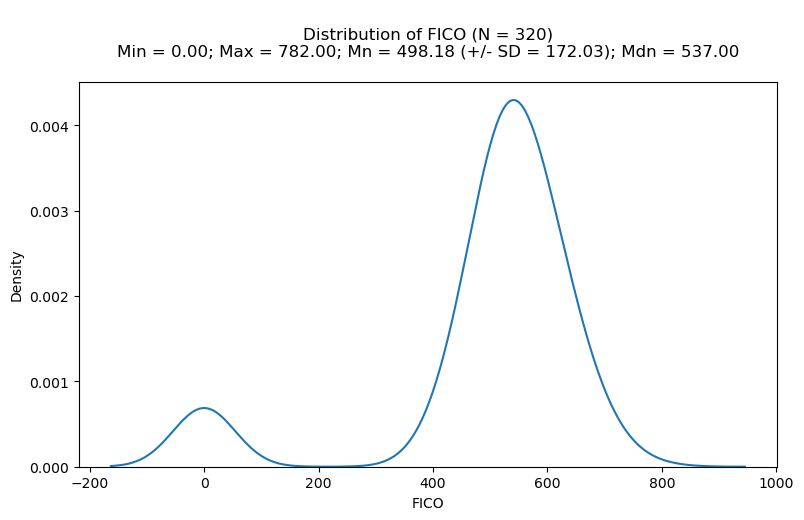

In [52]:
list_tmp = list(df_tmp['FICO'])
int_n = len(list_tmp)
flt_min = np.min(list_tmp)
flt_max = np.max(list_tmp)
flt_mn = np.mean(list_tmp)
flt_sd = np.std(list_tmp)
flt_mdn = np.median(list_tmp)
str_title = f"""
Distribution of FICO (N = {int_n})
Min = {flt_min:0.2f}; Max = {flt_max:0.2f}; Mn = {flt_mn:0.2f} (+/- SD = {flt_sd:0.2f}); Mdn = {flt_mdn:0.2f}
"""
# plot
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(str_title)
ax.set_xlabel('FICO')
sns.kdeplot(list_tmp, ax=ax)
plt.show()

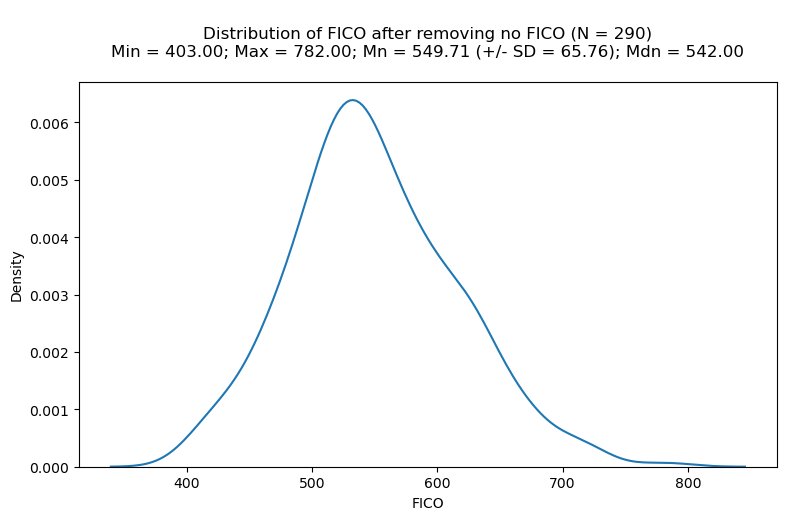

In [53]:
# rm 0s
list_tmp = list(df_tmp['FICO'])
list_tmp = [flt_fico for flt_fico in list_tmp if flt_fico > 0]
int_n = len(list_tmp)
flt_min = np.min(list_tmp)
flt_max = np.max(list_tmp)
flt_mn = np.mean(list_tmp)
flt_sd = np.std(list_tmp)
flt_mdn = np.median(list_tmp)
str_title = f"""
Distribution of FICO after removing no FICO (N = {int_n})
Min = {flt_min:0.2f}; Max = {flt_max:0.2f}; Mn = {flt_mn:0.2f} (+/- SD = {flt_sd:0.2f}); Mdn = {flt_mdn:0.2f}
"""
# plot
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(str_title)
ax.set_xlabel('FICO')
sns.kdeplot(list_tmp, ax=ax)
plt.show()

### Plot mean predictions by FICO quantile - All

In [54]:
int_n_quantiles_tmp = int_n_quantiles
while True:
    try:
        df_tmp['quantile'] = pd.qcut(
            df_tmp['FICO'], 
            q=int_n_quantiles_tmp, 
            labels=list(range(1, int_n_quantiles_tmp+1)),
            duplicates='drop',
        )
        break
    except ValueError:
        int_n_quantiles_tmp -= 1

# group
df_tmp['count'] = 1
df_tmp['min'] = df_tmp['FICO']
df_tmp['max'] = df_tmp['FICO']
df_grouped_tmp = df_tmp.groupby('quantile', as_index=False).agg({
    'count': 'sum',
    'min': 'min',
    'max': 'max',
    'FICO': 'mean',
    'yhat_ad_new': 'mean',
    'yhat_pd_new_logloss': 'mean',
    'yhat_lgd_new': 'mean',
    'ecnl_new_logloss': 'mean',
})
# create better quantile label
df_grouped_tmp['quantile_label'] = df_grouped_tmp.apply(
    lambda x: f'{x["min"]} - {x["max"]}',
    axis=1,
)
# show
df_grouped_tmp

,quantile,count,min,max,FICO,yhat_ad_new,yhat_pd_new_logloss,yhat_lgd_new,ecnl_new_logloss,quantile_label
0,1,64,0.0,472.0,237.148438,0.559025,0.294383,0.660536,0.457698,0.0 - 472.0
1,2,64,474.0,520.0,500.968750,0.547518,0.296599,0.657154,0.465362,474.0 - 520.0
2,3,65,521.0,550.0,535.892308,0.528020,0.251039,0.666205,0.397900,521.0 - 550.0
3,4,63,551.0,596.0,574.071429,0.476845,0.260371,0.660782,0.412402,551.0 - 596.0
4,5,64,598.0,782.0,643.390625,0.455385,0.269488,0.658933,0.423055,598.0 - 782.0


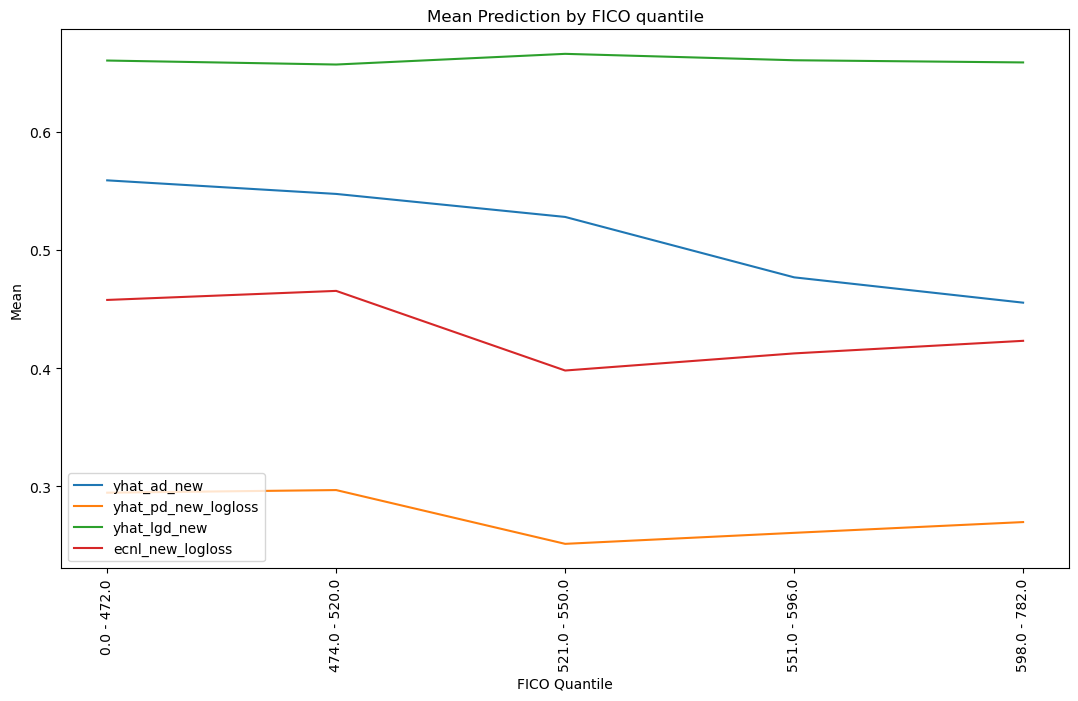

In [55]:
# line plots
list_cols = [
    'yhat_ad_new',
    'yhat_pd_new_logloss',
    'yhat_lgd_new',
    'ecnl_new_logloss',
]
# plot
fig, ax = plt.subplots(figsize=(13,7))
ax.set_title('Mean Prediction by FICO quantile')
ax.set_xlabel('FICO Quantile')
ax.set_ylabel('Mean')
for col in list_cols:
    ax.plot(df_grouped_tmp['quantile_label'].astype(str), df_grouped_tmp[col], label=col)
plt.legend(loc='lower left')
ax.set_xticklabels(df_grouped_tmp['quantile_label'].astype(str), rotation=90)
plt.show()

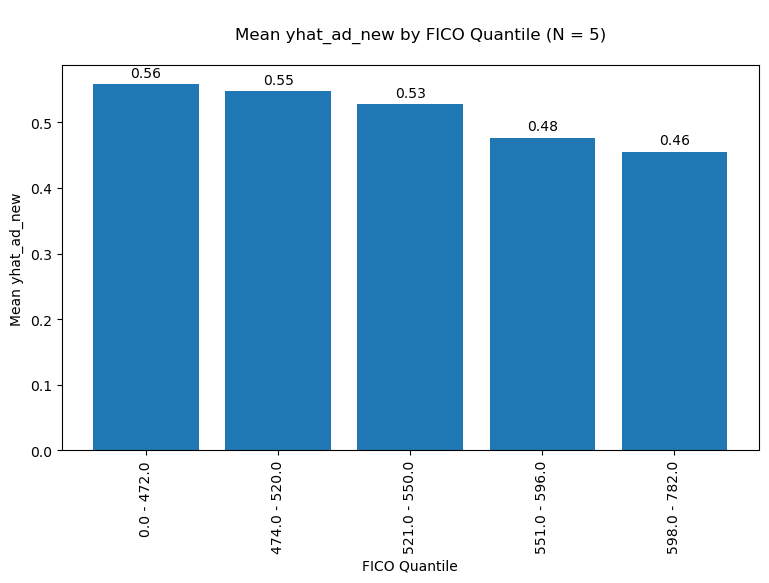

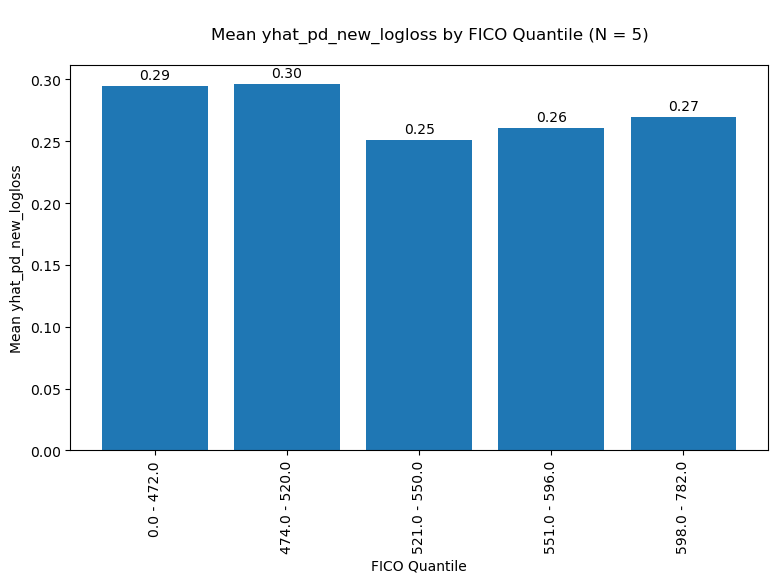

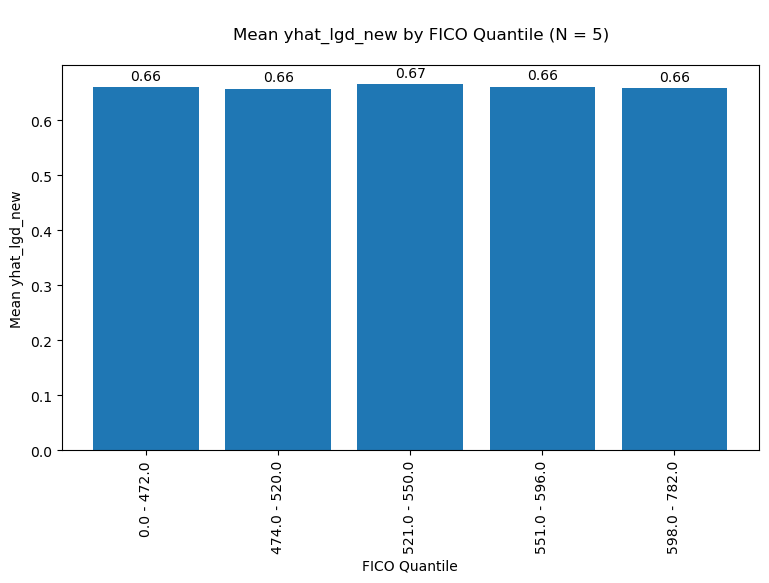

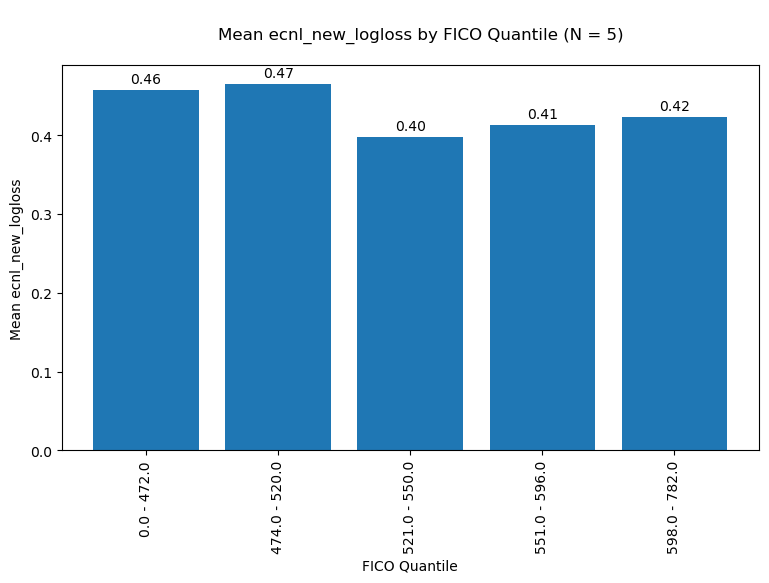

In [56]:
# bar plots
int_n = df_grouped_tmp.shape[0]
for col in list_cols:
    str_title = f"""
    Mean {col} by FICO Quantile (N = {int_n})
    """
    # ax
    fig, ax = plt.subplots(figsize=(9,5))
    # labels
    ax.set_title(str_title)
    ax.set_xlabel('FICO Quantile')
    ax.set_ylabel(f'Mean {col}')
    # plot
    bars = ax.bar(df_grouped_tmp['quantile_label'].astype(str), df_grouped_tmp[col])
    # bar labels
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:0.2f}',
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3),  # 3 points vertical offset
            textcoords="offset points",
            ha='center',
            va='bottom',
        )
    # labels
    ax.set_xticklabels(df_grouped_tmp['quantile_label'].astype(str), rotation=90)
    # show
    plt.show()

### Identity - All

In [57]:
df_grouped_tmp.sort_values(by='ecnl_new_logloss', ascending=True, inplace=True)
df_grouped_tmp

,quantile,count,min,max,FICO,yhat_ad_new,yhat_pd_new_logloss,yhat_lgd_new,ecnl_new_logloss,quantile_label
2,3,65,521.0,550.0,535.892308,0.528020,0.251039,0.666205,0.397900,521.0 - 550.0
3,4,63,551.0,596.0,574.071429,0.476845,0.260371,0.660782,0.412402,551.0 - 596.0
4,5,64,598.0,782.0,643.390625,0.455385,0.269488,0.658933,0.423055,598.0 - 782.0
0,1,64,0.0,472.0,237.148438,0.559025,0.294383,0.660536,0.457698,0.0 - 472.0
1,2,64,474.0,520.0,500.968750,0.547518,0.296599,0.657154,0.465362,474.0 - 520.0


### Distribution - BK

In [58]:
df_tmp = df_grouped[df_grouped['intopenbktype__app'] != 'nan'].copy()
# get prop na
flt_isnull = df_tmp['FICO'].isnull().mean()
print(f'Proportion with missing FICO: {flt_isnull:0.2f}')

# fill missing FICO with 0
df_tmp['FICO'] = df_tmp['FICO'].fillna(0)

# get prop na
flt_isnull = df_tmp['FICO'].isnull().mean()
print(f'Proportion with missing FICO after imputing: {flt_isnull:0.2f}')

Proportion with missing FICO: 0.00
Proportion with missing FICO after imputing: 0.00


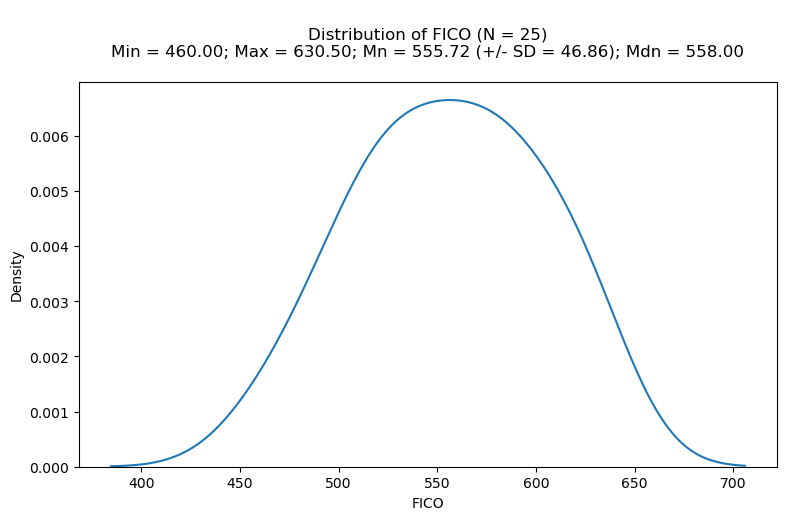

In [59]:
list_tmp = list(df_tmp['FICO'])
int_n = len(list_tmp)
flt_min = np.min(list_tmp)
flt_max = np.max(list_tmp)
flt_mn = np.mean(list_tmp)
flt_sd = np.std(list_tmp)
flt_mdn = np.median(list_tmp)
str_title = f"""
Distribution of FICO (N = {int_n})
Min = {flt_min:0.2f}; Max = {flt_max:0.2f}; Mn = {flt_mn:0.2f} (+/- SD = {flt_sd:0.2f}); Mdn = {flt_mdn:0.2f}
"""
# plot
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(str_title)
ax.set_xlabel('FICO')
sns.kdeplot(list_tmp, ax=ax)
plt.show()

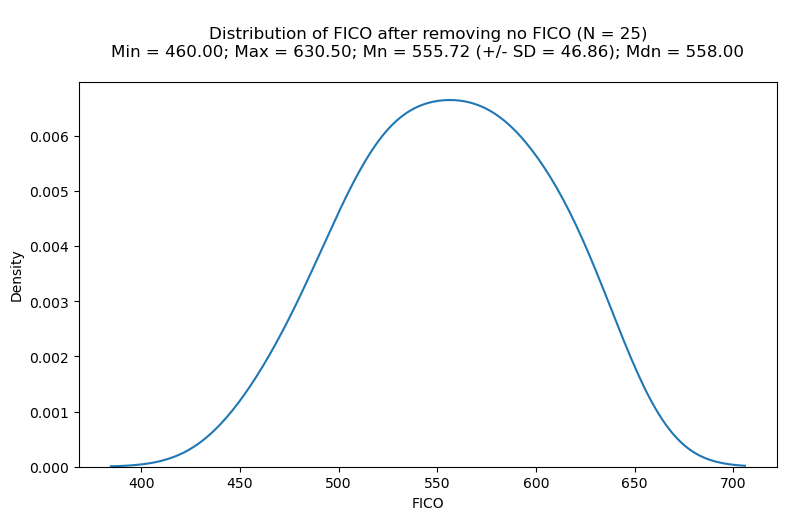

In [60]:
# rm 0s
list_tmp = list(df_tmp['FICO'])
list_tmp = [flt_fico for flt_fico in list_tmp if flt_fico > 0]
int_n = len(list_tmp)
flt_min = np.min(list_tmp)
flt_max = np.max(list_tmp)
flt_mn = np.mean(list_tmp)
flt_sd = np.std(list_tmp)
flt_mdn = np.median(list_tmp)
str_title = f"""
Distribution of FICO after removing no FICO (N = {int_n})
Min = {flt_min:0.2f}; Max = {flt_max:0.2f}; Mn = {flt_mn:0.2f} (+/- SD = {flt_sd:0.2f}); Mdn = {flt_mdn:0.2f}
"""
# plot
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(str_title)
ax.set_xlabel('FICO')
sns.kdeplot(list_tmp, ax=ax)
plt.show()

### Plot mean predictions by FICO quantile - BK

In [61]:
int_n_quantiles_tmp = int_n_quantiles
while True:
    try:
        df_tmp['quantile'] = pd.qcut(
            df_tmp['FICO'], 
            q=int_n_quantiles_tmp, 
            labels=list(range(1, int_n_quantiles_tmp+1)),
            duplicates='drop',
        )
        break
    except ValueError:
        int_n_quantiles_tmp -= 1

# group
df_tmp['count'] = 1
df_tmp['min'] = df_tmp['FICO']
df_tmp['max'] = df_tmp['FICO']
df_grouped_tmp = df_tmp.groupby('quantile', as_index=False).agg({
    'count': 'sum',
    'min': 'min',
    'max': 'max',
    'FICO': 'mean',
    'yhat_ad_new': 'mean',
    'yhat_pd_new_logloss': 'mean',
    'yhat_lgd_new': 'mean',
    'ecnl_new_logloss': 'mean',
})
# create better quantile label
df_grouped_tmp['quantile_label'] = df_grouped_tmp.apply(
    lambda x: f'{x["min"]} - {x["max"]}',
    axis=1,
)
# show
df_grouped_tmp

,quantile,count,min,max,FICO,yhat_ad_new,yhat_pd_new_logloss,yhat_lgd_new,ecnl_new_logloss,quantile_label
0,1,5,460.0,511.0,489.600000,0.320067,0.239864,0.712056,0.399625,460.0 - 511.0
1,2,5,515.0,541.0,526.900000,0.336341,0.252477,0.687339,0.408842,515.0 - 541.0
2,3,6,543.0,573.0,559.166667,0.220423,0.158729,0.657949,0.248980,543.0 - 573.0
3,4,4,584.0,595.0,587.500000,0.208317,0.166410,0.656304,0.260175,584.0 - 595.0
4,5,5,608.0,630.5,621.100000,0.275704,0.167395,0.681219,0.269683,608.0 - 630.5


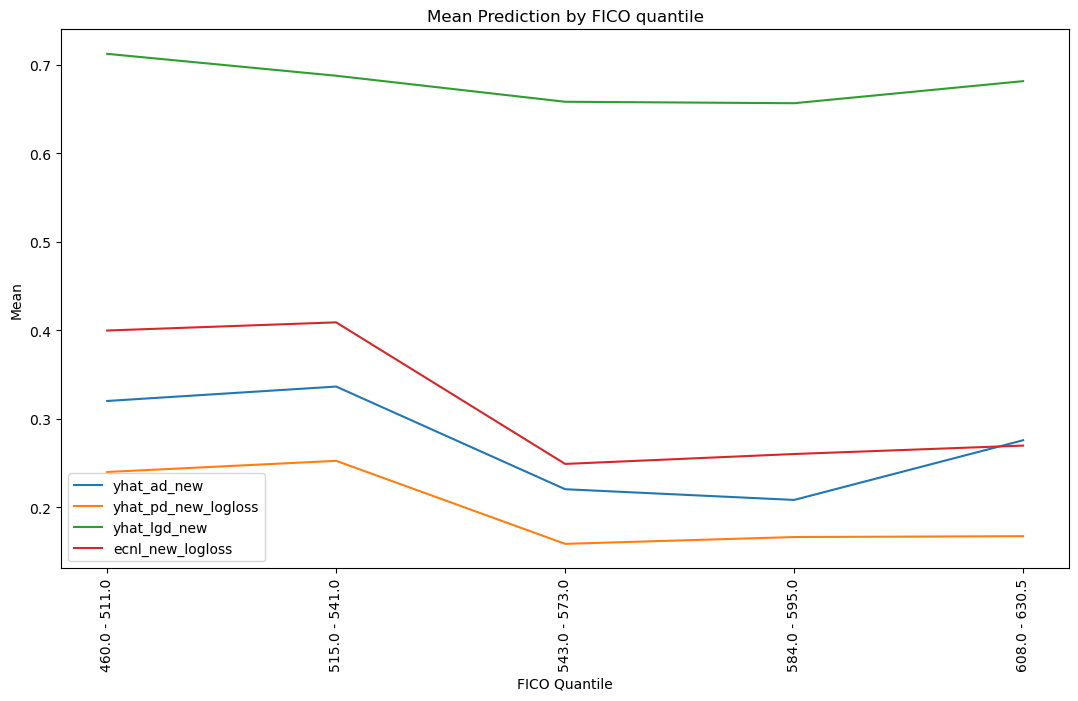

In [62]:
# line plots
list_cols = [
    'yhat_ad_new',
    'yhat_pd_new_logloss',
    'yhat_lgd_new',
    'ecnl_new_logloss',
]
# plot
fig, ax = plt.subplots(figsize=(13,7))
ax.set_title('Mean Prediction by FICO quantile')
ax.set_xlabel('FICO Quantile')
ax.set_ylabel('Mean')
for col in list_cols:
    ax.plot(df_grouped_tmp['quantile_label'].astype(str), df_grouped_tmp[col], label=col)
plt.legend(loc='lower left')
ax.set_xticklabels(df_grouped_tmp['quantile_label'].astype(str), rotation=90)
plt.show()

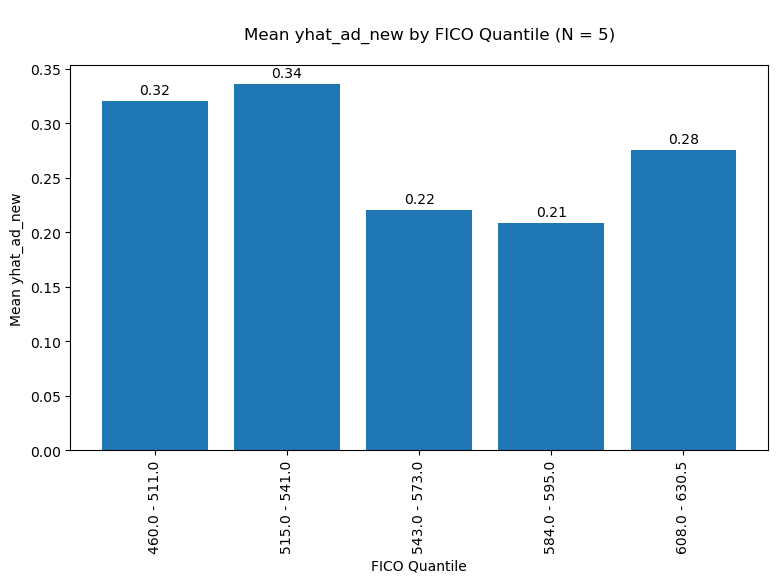

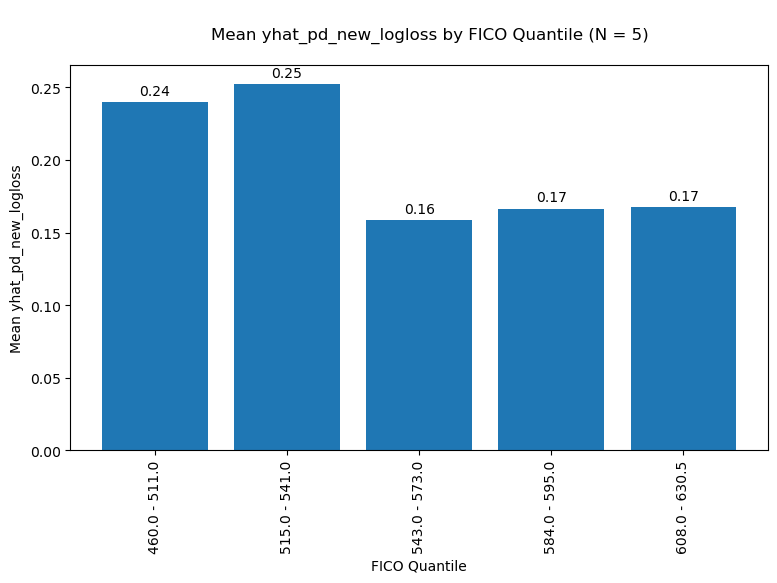

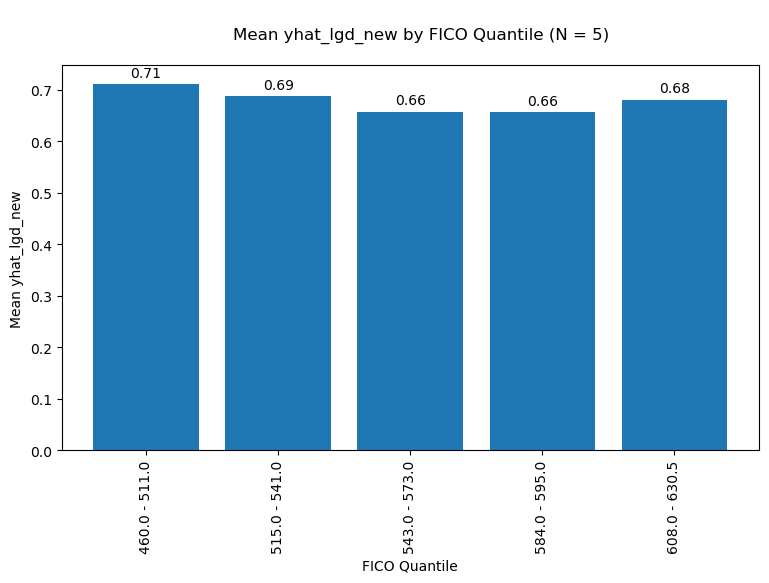

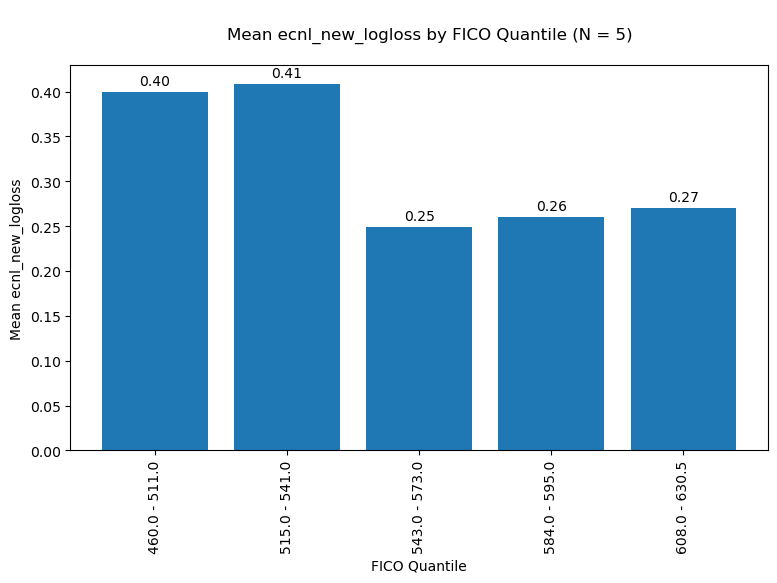

In [63]:
# bar plots
int_n = df_grouped_tmp.shape[0]
for col in list_cols:
    str_title = f"""
    Mean {col} by FICO Quantile (N = {int_n})
    """
    # ax
    fig, ax = plt.subplots(figsize=(9,5))
    # labels
    ax.set_title(str_title)
    ax.set_xlabel('FICO Quantile')
    ax.set_ylabel(f'Mean {col}')
    # plot
    bars = ax.bar(df_grouped_tmp['quantile_label'].astype(str), df_grouped_tmp[col])
    # bar labels
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:0.2f}',
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3),  # 3 points vertical offset
            textcoords="offset points",
            ha='center',
            va='bottom',
        )
    # labels
    ax.set_xticklabels(df_grouped_tmp['quantile_label'].astype(str), rotation=90)
    # show
    plt.show()

### Identity - BK

In [64]:
df_grouped_tmp.sort_values(by='ecnl_new_logloss', ascending=True, inplace=True)
df_grouped_tmp

,quantile,count,min,max,FICO,yhat_ad_new,yhat_pd_new_logloss,yhat_lgd_new,ecnl_new_logloss,quantile_label
2,3,6,543.0,573.0,559.166667,0.220423,0.158729,0.657949,0.248980,543.0 - 573.0
3,4,4,584.0,595.0,587.500000,0.208317,0.166410,0.656304,0.260175,584.0 - 595.0
4,5,5,608.0,630.5,621.100000,0.275704,0.167395,0.681219,0.269683,608.0 - 630.5
0,1,5,460.0,511.0,489.600000,0.320067,0.239864,0.712056,0.399625,460.0 - 511.0
1,2,5,515.0,541.0,526.900000,0.336341,0.252477,0.687339,0.408842,515.0 - 541.0


### Distribution - No BK

In [65]:
df_tmp = df_grouped[df_grouped['intopenbktype__app'] == 'nan'].copy()
# get prop na
flt_isnull = df_tmp['FICO'].isnull().mean()
print(f'Proportion with missing FICO: {flt_isnull:0.2f}')

# fill missing FICO with 0
df_tmp['FICO'] = df_tmp['FICO'].fillna(0)

# get prop na
flt_isnull = df_tmp['FICO'].isnull().mean()
print(f'Proportion with missing FICO after imputing: {flt_isnull:0.2f}')

Proportion with missing FICO: 0.10
Proportion with missing FICO after imputing: 0.00


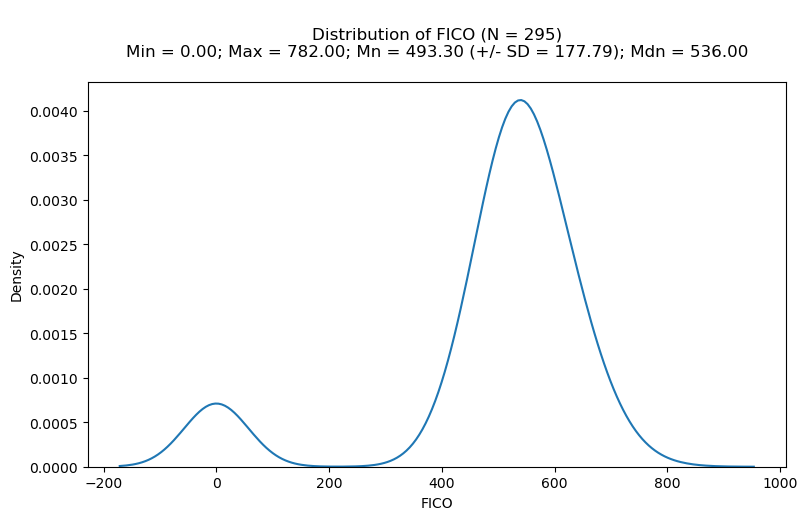

In [66]:
list_tmp = list(df_tmp['FICO'])
int_n = len(list_tmp)
flt_min = np.min(list_tmp)
flt_max = np.max(list_tmp)
flt_mn = np.mean(list_tmp)
flt_sd = np.std(list_tmp)
flt_mdn = np.median(list_tmp)
str_title = f"""
Distribution of FICO (N = {int_n})
Min = {flt_min:0.2f}; Max = {flt_max:0.2f}; Mn = {flt_mn:0.2f} (+/- SD = {flt_sd:0.2f}); Mdn = {flt_mdn:0.2f}
"""
# plot
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(str_title)
ax.set_xlabel('FICO')
sns.kdeplot(list_tmp, ax=ax)
plt.show()

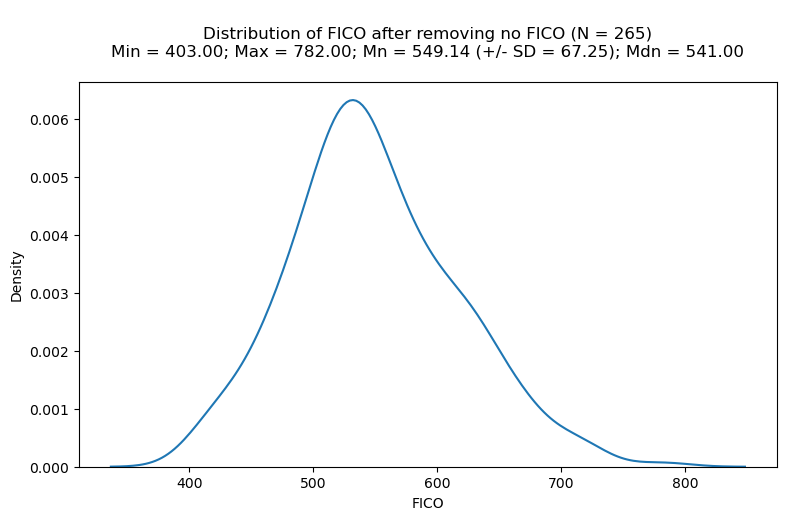

In [67]:
# rm 0s
list_tmp = list(df_tmp['FICO'])
list_tmp = [flt_fico for flt_fico in list_tmp if flt_fico > 0]
int_n = len(list_tmp)
flt_min = np.min(list_tmp)
flt_max = np.max(list_tmp)
flt_mn = np.mean(list_tmp)
flt_sd = np.std(list_tmp)
flt_mdn = np.median(list_tmp)
str_title = f"""
Distribution of FICO after removing no FICO (N = {int_n})
Min = {flt_min:0.2f}; Max = {flt_max:0.2f}; Mn = {flt_mn:0.2f} (+/- SD = {flt_sd:0.2f}); Mdn = {flt_mdn:0.2f}
"""
# plot
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(str_title)
ax.set_xlabel('FICO')
sns.kdeplot(list_tmp, ax=ax)
plt.show()

### Plot mean predictions by FICO quantile - No BK

In [68]:
int_n_quantiles_tmp = int_n_quantiles
while True:
    try:
        df_tmp['quantile'] = pd.qcut(
            df_tmp['FICO'], 
            q=int_n_quantiles_tmp, 
            labels=list(range(1, int_n_quantiles_tmp+1)),
            duplicates='drop',
        )
        break
    except ValueError:
        int_n_quantiles_tmp -= 1

# group
df_tmp['count'] = 1
df_tmp['min'] = df_tmp['FICO']
df_tmp['max'] = df_tmp['FICO']
df_grouped_tmp = df_tmp.groupby('quantile', as_index=False).agg({
    'count': 'sum',
    'min': 'min',
    'max': 'max',
    'FICO': 'mean',
    'yhat_ad_new': 'mean',
    'yhat_pd_new_logloss': 'mean',
    'yhat_lgd_new': 'mean',
    'ecnl_new_logloss': 'mean',
})
# create better quantile label
df_grouped_tmp['quantile_label'] = df_grouped_tmp.apply(
    lambda x: f'{x["min"]} - {x["max"]}',
    axis=1,
)
# show
df_grouped_tmp

,quantile,count,min,max,FICO,yhat_ad_new,yhat_pd_new_logloss,yhat_lgd_new,ecnl_new_logloss,quantile_label
0,1,59,0.0,470.0,217.500000,0.553345,0.299678,0.659605,0.466025,0.0 - 470.0
1,2,59,471.0,518.0,497.771186,0.574961,0.293622,0.650311,0.456593,471.0 - 518.0
2,3,61,519.0,549.0,534.393443,0.555128,0.260808,0.666951,0.414209,519.0 - 549.0
3,4,57,550.0,596.0,572.850877,0.514220,0.272807,0.661856,0.432323,550.0 - 596.0
4,5,59,598.0,782.0,645.279661,0.470612,0.278140,0.657045,0.436053,598.0 - 782.0


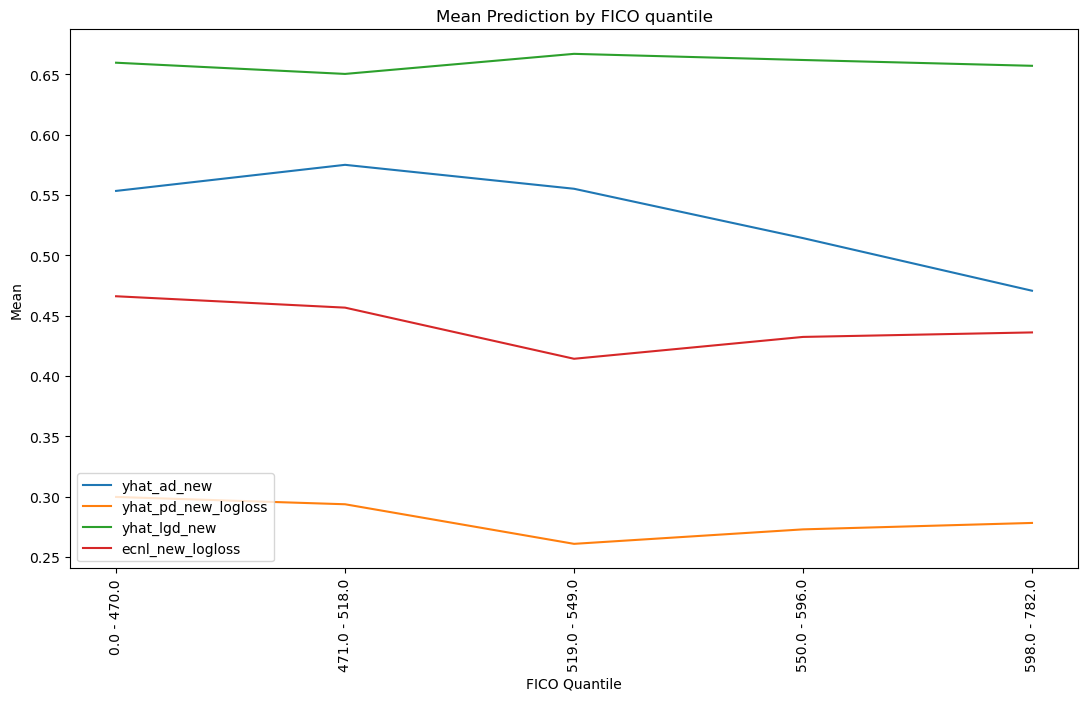

In [69]:
# line plots
list_cols = [
    'yhat_ad_new',
    'yhat_pd_new_logloss',
    'yhat_lgd_new',
    'ecnl_new_logloss',
]
# plot
fig, ax = plt.subplots(figsize=(13,7))
ax.set_title('Mean Prediction by FICO quantile')
ax.set_xlabel('FICO Quantile')
ax.set_ylabel('Mean')
for col in list_cols:
    ax.plot(df_grouped_tmp['quantile_label'].astype(str), df_grouped_tmp[col], label=col)
plt.legend(loc='lower left')
ax.set_xticklabels(df_grouped_tmp['quantile_label'].astype(str), rotation=90)
plt.show()

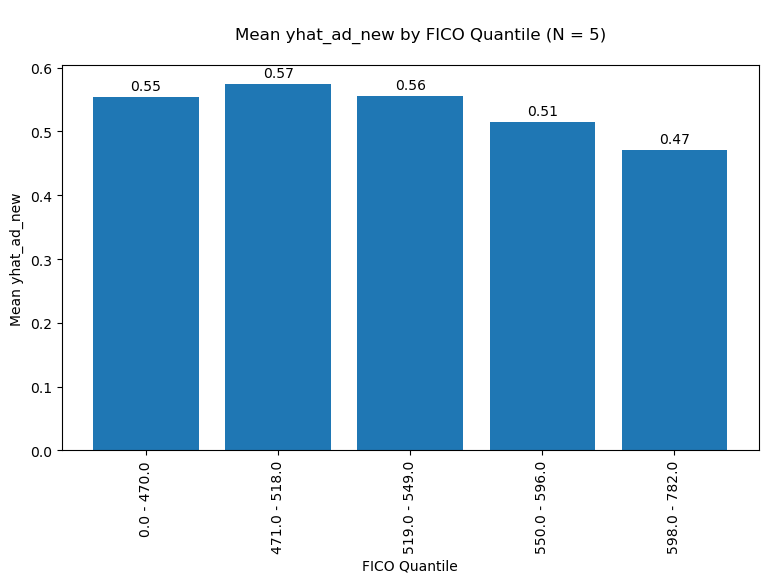

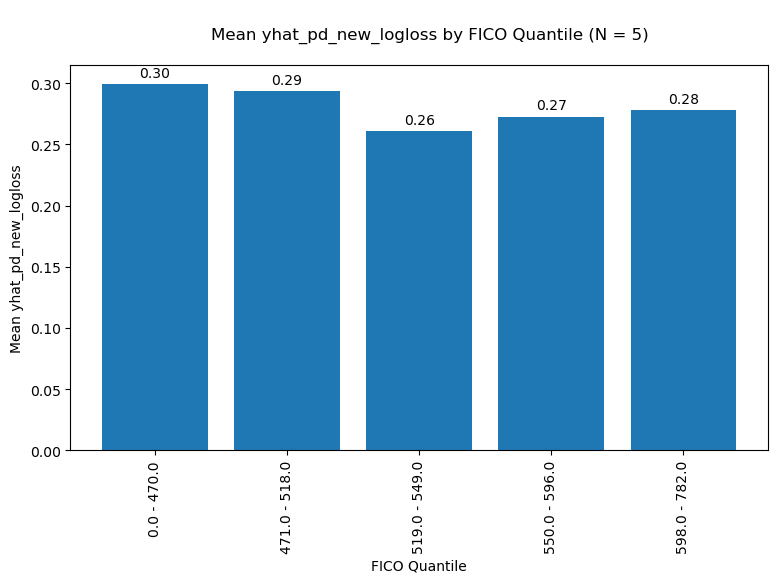

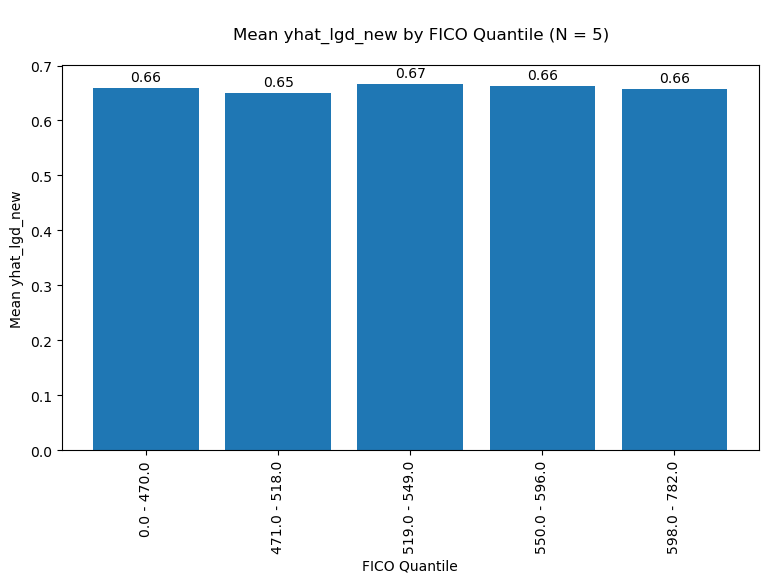

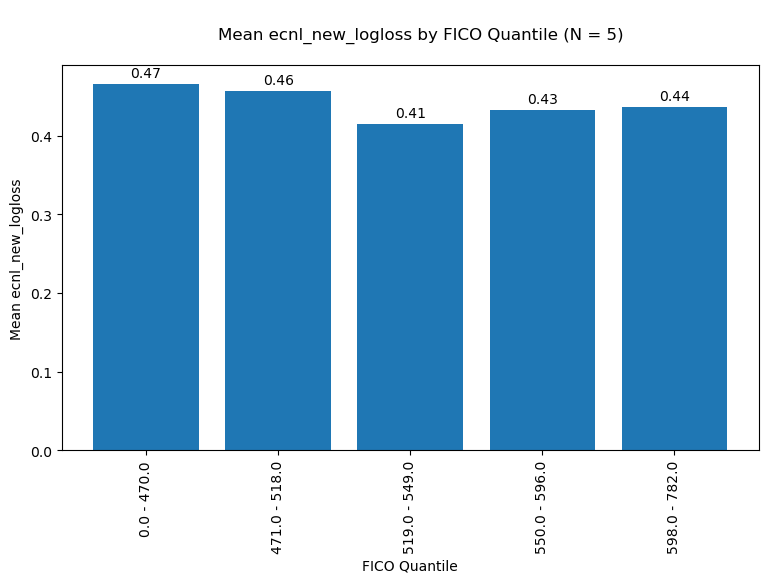

In [70]:
# bar plots
int_n = df_grouped_tmp.shape[0]
for col in list_cols:
    str_title = f"""
    Mean {col} by FICO Quantile (N = {int_n})
    """
    # ax
    fig, ax = plt.subplots(figsize=(9,5))
    # labels
    ax.set_title(str_title)
    ax.set_xlabel('FICO Quantile')
    ax.set_ylabel(f'Mean {col}')
    # plot
    bars = ax.bar(df_grouped_tmp['quantile_label'].astype(str), df_grouped_tmp[col])
    # bar labels
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:0.2f}',
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3),  # 3 points vertical offset
            textcoords="offset points",
            ha='center',
            va='bottom',
        )
    # labels
    ax.set_xticklabels(df_grouped_tmp['quantile_label'].astype(str), rotation=90)
    # show
    plt.show()

### Identity - No BK

In [71]:
df_grouped_tmp.sort_values(by='ecnl_new_logloss', ascending=True, inplace=True)
df_grouped_tmp

,quantile,count,min,max,FICO,yhat_ad_new,yhat_pd_new_logloss,yhat_lgd_new,ecnl_new_logloss,quantile_label
2,3,61,519.0,549.0,534.393443,0.555128,0.260808,0.666951,0.414209,519.0 - 549.0
3,4,57,550.0,596.0,572.850877,0.514220,0.272807,0.661856,0.432323,550.0 - 596.0
4,5,59,598.0,782.0,645.279661,0.470612,0.278140,0.657045,0.436053,598.0 - 782.0
1,2,59,471.0,518.0,497.771186,0.574961,0.293622,0.650311,0.456593,471.0 - 518.0
0,1,59,0.0,470.0,217.500000,0.553345,0.299678,0.659605,0.466025,0.0 - 470.0


### Distribution - BK 7

In [72]:
# df_tmp = df_grouped[df_grouped['intopenbktype__app'] == '7.0'].copy()
# # get prop na
# flt_isnull = df_tmp['FICO'].isnull().mean()
# print(f'Proportion with missing FICO: {flt_isnull:0.2f}')

# # fill missing FICO with 0
# df_tmp['FICO'] = df_tmp['FICO'].fillna(0)

# # get prop na
# flt_isnull = df_tmp['FICO'].isnull().mean()
# print(f'Proportion with missing FICO after imputing: {flt_isnull:0.2f}')

In [73]:
# list_tmp = list(df_tmp['FICO'])
# int_n = len(list_tmp)
# flt_min = np.min(list_tmp)
# flt_max = np.max(list_tmp)
# flt_mn = np.mean(list_tmp)
# flt_sd = np.std(list_tmp)
# flt_mdn = np.median(list_tmp)
# str_title = f"""
# Distribution of FICO (N = {int_n})
# Min = {flt_min:0.2f}; Max = {flt_max:0.2f}; Mn = {flt_mn:0.2f} (+/- SD = {flt_sd:0.2f}); Mdn = {flt_mdn:0.2f}
# """
# # plot
# fig, ax = plt.subplots(figsize=(9,5))
# ax.set_title(str_title)
# ax.set_xlabel('FICO')
# sns.kdeplot(list_tmp, ax=ax)
# plt.show()

In [74]:
# # rm 0s
# list_tmp = list(df_tmp['FICO'])
# list_tmp = [flt_fico for flt_fico in list_tmp if flt_fico > 0]
# int_n = len(list_tmp)
# flt_min = np.min(list_tmp)
# flt_max = np.max(list_tmp)
# flt_mn = np.mean(list_tmp)
# flt_sd = np.std(list_tmp)
# flt_mdn = np.median(list_tmp)
# str_title = f"""
# Distribution of FICO after removing no FICO (N = {int_n})
# Min = {flt_min:0.2f}; Max = {flt_max:0.2f}; Mn = {flt_mn:0.2f} (+/- SD = {flt_sd:0.2f}); Mdn = {flt_mdn:0.2f}
# """
# # plot
# fig, ax = plt.subplots(figsize=(9,5))
# ax.set_title(str_title)
# ax.set_xlabel('FICO')
# sns.kdeplot(list_tmp, ax=ax)
# plt.show()

### Plot mean predictions by FICO quantile - BK 7

In [75]:
# int_n_quantiles_tmp = int_n_quantiles
# while True:
#     try:
#         df_tmp['quantile'] = pd.qcut(
#             df_tmp['FICO'], 
#             q=int_n_quantiles_tmp, 
#             labels=list(range(1, int_n_quantiles_tmp+1)),
#             duplicates='drop',
#         )
#         break
#     except ValueError:
#         int_n_quantiles_tmp -= 1

# # group
# df_tmp['count'] = 1
# df_tmp['min'] = df_tmp['FICO']
# df_tmp['max'] = df_tmp['FICO']
# df_grouped_tmp = df_tmp.groupby('quantile', as_index=False).agg({
#     'count': 'sum',
#     'min': 'min',
#     'max': 'max',
#     'FICO': 'mean',
#     'yhat_ad_new': 'mean',
#     'yhat_pd_new_logloss': 'mean',
#     'yhat_lgd_new': 'mean',
#     'ecnl_new_logloss': 'mean',
# })
# # create better quantile label
# df_grouped_tmp['quantile_label'] = df_grouped_tmp.apply(
#     lambda x: f'{x["min"]} - {x["max"]}',
#     axis=1,
# )
# # show
# df_grouped_tmp

In [76]:
# # line plots
# list_cols = [
#     'yhat_ad_new',
#     'yhat_pd_new_logloss',
#     'yhat_lgd_new',
#     'ecnl_new_logloss',
# ]
# # plot
# fig, ax = plt.subplots(figsize=(13,7))
# ax.set_title('Mean Prediction by FICO quantile')
# ax.set_xlabel('FICO Quantile')
# ax.set_ylabel('Mean')
# for col in list_cols:
#     ax.plot(df_grouped_tmp['quantile_label'].astype(str), df_grouped_tmp[col], label=col)
# plt.legend(loc='lower left')
# ax.set_xticklabels(df_grouped_tmp['quantile_label'].astype(str), rotation=90)
# plt.show()

In [77]:
# # bar plots
# int_n = df_grouped_tmp.shape[0]
# for col in list_cols:
#     str_title = f"""
#     Mean {col} by FICO Quantile (N = {int_n})
#     """
#     # ax
#     fig, ax = plt.subplots(figsize=(9,5))
#     # labels
#     ax.set_title(str_title)
#     ax.set_xlabel('FICO Quantile')
#     ax.set_ylabel(f'Mean {col}')
#     # plot
#     bars = ax.bar(df_grouped_tmp['quantile_label'].astype(str), df_grouped_tmp[col])
#     # bar labels
#     for bar in bars:
#         height = bar.get_height()
#         ax.annotate(f'{height:0.2f}',
#             xy=(bar.get_x() + bar.get_width() / 2, height),
#             xytext=(0, 3),  # 3 points vertical offset
#             textcoords="offset points",
#             ha='center',
#             va='bottom',
#         )
#     # labels
#     ax.set_xticklabels(df_grouped_tmp['quantile_label'].astype(str), rotation=90)
#     # show
#     plt.show()

### Identity - BK 7

In [78]:
# df_grouped_tmp.sort_values(by='ecnl_new_logloss', ascending=True, inplace=True)
# df_grouped_tmp

### Distribution - BK 13

In [79]:
# df_tmp = df_grouped[df_grouped['intopenbktype__app'] == '13.0'].copy()
# # get prop na
# flt_isnull = df_tmp['FICO'].isnull().mean()
# print(f'Proportion with missing FICO: {flt_isnull:0.2f}')

# # fill missing FICO with 0
# df_tmp['FICO'] = df_tmp['FICO'].fillna(0)

# # get prop na
# flt_isnull = df_tmp['FICO'].isnull().mean()
# print(f'Proportion with missing FICO after imputing: {flt_isnull:0.2f}')

In [80]:
# list_tmp = list(df_tmp['FICO'])
# int_n = len(list_tmp)
# flt_min = np.min(list_tmp)
# flt_max = np.max(list_tmp)
# flt_mn = np.mean(list_tmp)
# flt_sd = np.std(list_tmp)
# flt_mdn = np.median(list_tmp)
# str_title = f"""
# Distribution of FICO (N = {int_n})
# Min = {flt_min:0.2f}; Max = {flt_max:0.2f}; Mn = {flt_mn:0.2f} (+/- SD = {flt_sd:0.2f}); Mdn = {flt_mdn:0.2f}
# """
# # plot
# fig, ax = plt.subplots(figsize=(9,5))
# ax.set_title(str_title)
# ax.set_xlabel('FICO')
# sns.kdeplot(list_tmp, ax=ax)
# plt.show()

In [81]:
# # rm 0s
# list_tmp = list(df_tmp['FICO'])
# list_tmp = [flt_fico for flt_fico in list_tmp if flt_fico > 0]
# int_n = len(list_tmp)
# flt_min = np.min(list_tmp)
# flt_max = np.max(list_tmp)
# flt_mn = np.mean(list_tmp)
# flt_sd = np.std(list_tmp)
# flt_mdn = np.median(list_tmp)
# str_title = f"""
# Distribution of FICO after removing no FICO (N = {int_n})
# Min = {flt_min:0.2f}; Max = {flt_max:0.2f}; Mn = {flt_mn:0.2f} (+/- SD = {flt_sd:0.2f}); Mdn = {flt_mdn:0.2f}
# """
# # plot
# fig, ax = plt.subplots(figsize=(9,5))
# ax.set_title(str_title)
# ax.set_xlabel('FICO')
# sns.kdeplot(list_tmp, ax=ax)
# plt.show()

### Plot mean predictions by FICO quantile - BK 13

In [82]:
# int_n_quantiles_tmp = int_n_quantiles
# while True:
#     try:
#         df_tmp['quantile'] = pd.qcut(
#             df_tmp['FICO'], 
#             q=int_n_quantiles_tmp, 
#             labels=list(range(1, int_n_quantiles_tmp+1)),
#             duplicates='drop',
#         )
#         break
#     except ValueError:
#         int_n_quantiles_tmp -= 1

# # group
# df_tmp['count'] = 1
# df_tmp['min'] = df_tmp['FICO']
# df_tmp['max'] = df_tmp['FICO']
# df_grouped_tmp = df_tmp.groupby('quantile', as_index=False).agg({
#     'count': 'sum',
#     'min': 'min',
#     'max': 'max',
#     'FICO': 'mean',
#     'yhat_ad_new': 'mean',
#     'yhat_pd_new_logloss': 'mean',
#     'yhat_lgd_new': 'mean',
#     'ecnl_new_logloss': 'mean',
# })
# # create better quantile label
# df_grouped_tmp['quantile_label'] = df_grouped_tmp.apply(
#     lambda x: f'{x["min"]} - {x["max"]}',
#     axis=1,
# )
# # show
# df_grouped_tmp

In [83]:
# # line plots
# list_cols = [
#     'yhat_ad_new',
#     'yhat_pd_new_logloss',
#     'yhat_lgd_new',
#     'ecnl_new_logloss',
# ]
# # plot
# fig, ax = plt.subplots(figsize=(13,7))
# ax.set_title('Mean Prediction by FICO quantile')
# ax.set_xlabel('FICO Quantile')
# ax.set_ylabel('Mean')
# for col in list_cols:
#     ax.plot(df_grouped_tmp['quantile_label'].astype(str), df_grouped_tmp[col], label=col)
# plt.legend(loc='lower left')
# ax.set_xticklabels(df_grouped_tmp['quantile_label'].astype(str), rotation=90)
# plt.show()

In [84]:
# # bar plots
# int_n = df_grouped_tmp.shape[0]
# for col in list_cols:
#     str_title = f"""
#     Mean {col} by FICO Quantile (N = {int_n})
#     """
#     # ax
#     fig, ax = plt.subplots(figsize=(9,5))
#     # labels
#     ax.set_title(str_title)
#     ax.set_xlabel('FICO Quantile')
#     ax.set_ylabel(f'Mean {col}')
#     # plot
#     bars = ax.bar(df_grouped_tmp['quantile_label'].astype(str), df_grouped_tmp[col])
#     # bar labels
#     for bar in bars:
#         height = bar.get_height()
#         ax.annotate(f'{height:0.2f}',
#             xy=(bar.get_x() + bar.get_width() / 2, height),
#             xytext=(0, 3),  # 3 points vertical offset
#             textcoords="offset points",
#             ha='center',
#             va='bottom',
#         )
#     # labels
#     ax.set_xticklabels(df_grouped_tmp['quantile_label'].astype(str), rotation=90)
#     # show
#     plt.show()

### Identity - BK 13

In [85]:
# df_grouped_tmp.sort_values(by='ecnl_new_logloss', ascending=True, inplace=True)
# df_grouped_tmp

### Print AD means

In [86]:
# print means
list_str_ad = [
    'yhat_ad_old',
    'yhat_ad_new',
]
for str_ad in list_str_ad:
    flt_mean = df_grouped[str_ad].mean()
    print(f'{str_ad} - Mean = {flt_mean:0.4f}')
    print()

yhat_ad_old - Mean = 0.3390

yhat_ad_new - Mean = 0.5135



### Print PD means

In [87]:
list_str_pd = [
    'genxi_raw_pd',
    #'genxi_factor_pd',
    #'yhat_pd_old',
    'yhat_pd_new_logloss',
    #'yhat_pd_new_auc',
]
for str_pd in list_str_pd:
    flt_mean = df_grouped[str_pd].mean()
    print(f'{str_pd} - Mean = {flt_mean:0.4f}')
    print()

genxi_raw_pd - Mean = 0.2338

yhat_pd_new_logloss - Mean = 0.2743



### Print LGD means

In [88]:
list_str_lgd = [
    'genxi_raw_lgd',
    #'genxi_factor_lgd',
    #'yhat_lgd_old',
    'yhat_lgd_new',
]
for str_lgd in list_str_lgd:
    flt_mean = df_grouped[str_lgd].mean()
    print(f'{str_lgd} - Mean = {flt_mean:0.4f}')
    print()

genxi_raw_lgd - Mean = 0.4499

yhat_lgd_new - Mean = 0.6607



### Print ECNL means

In [89]:
# print means
list_str_ecnl = [
    'genxi_raw_ecnl_mod',
    'genxi_factor_ecnl',
    #'ecnl_old',
    'ecnl_new_logloss',
    #'ecnl_new_auc',
]
for str_ecnl in list_str_ecnl:
    flt_mean = df_grouped[str_ecnl].mean()
    print(f'{str_ecnl} - Mean = {flt_mean:0.4f}')
    print()

genxi_raw_ecnl_mod - Mean = 0.1782

genxi_factor_ecnl - Mean = 0.2833

ecnl_new_logloss - Mean = 0.4312



### AD to Old PD

In [90]:
# fig, ax = plt.subplots(figsize=(9,5))
# ax.set_title('New AD to Old PD')
# ax.set_xlabel('New AD')
# ax.set_ylabel('Old PD')
# ax.scatter(df_grouped['yhat_ad_new'], df_grouped['yhat_pd_old'], alpha=0.2)
# plt.show()

### AD to New PD Optimized for Logloss

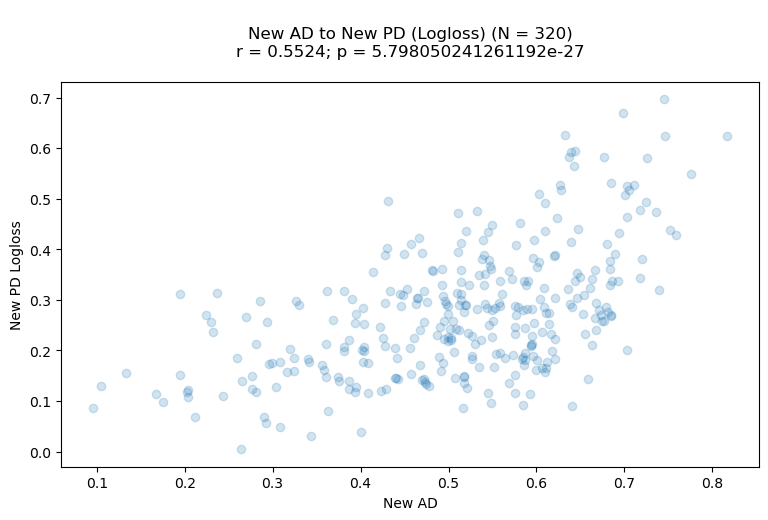

In [91]:
int_n = df_grouped.shape[0]
x = df_grouped['yhat_ad_new']
y = df_grouped['yhat_pd_new_logloss']
flt_r, flt_p = pearsonr(x, y)
str_title = f"""
New AD to New PD (Logloss) (N = {int_n})
r = {flt_r:0.4f}; p = {flt_p}
"""
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(str_title)
ax.set_xlabel('New AD')
ax.set_ylabel('New PD Logloss')
ax.scatter(x, y, alpha=0.2)
plt.show()

### AD to New PD Optimized for AUC

In [92]:
# fig, ax = plt.subplots(figsize=(9,5))
# ax.set_title('New AD to New PD (AUC)')
# ax.set_xlabel('New AD')
# ax.set_ylabel('New PD AUC')
# ax.scatter(df_grouped['yhat_ad_new'], df_grouped['yhat_pd_new_auc'], alpha=0.2)
# plt.show()

### Old ECNL to New ECNL Optimized for Logloss

In [93]:
# fig, ax = plt.subplots(figsize=(9,5))
# ax.set_title('Old ECNL to New ECNL (Logloss)')
# ax.set_xlabel('Old ECNL')
# ax.set_ylabel('New ECNL Logloss')
# ax.scatter(df_grouped['ecnl_old'], df_grouped['ecnl_new_logloss'], alpha=0.2)
# plt.show()

### Old ECNL to New ECNL Optimized for AUC

In [94]:
# fig, ax = plt.subplots(figsize=(9,5))
# ax.set_title('Old ECNL to New ECNL (AUC)')
# ax.set_xlabel('Old ECNL')
# ax.set_ylabel('New ECNL AUC')
# ax.scatter(df_grouped['ecnl_old'], df_grouped['ecnl_new_auc'], alpha=0.2)
# plt.show()

### AD to New ECNL Optimized for Logloss

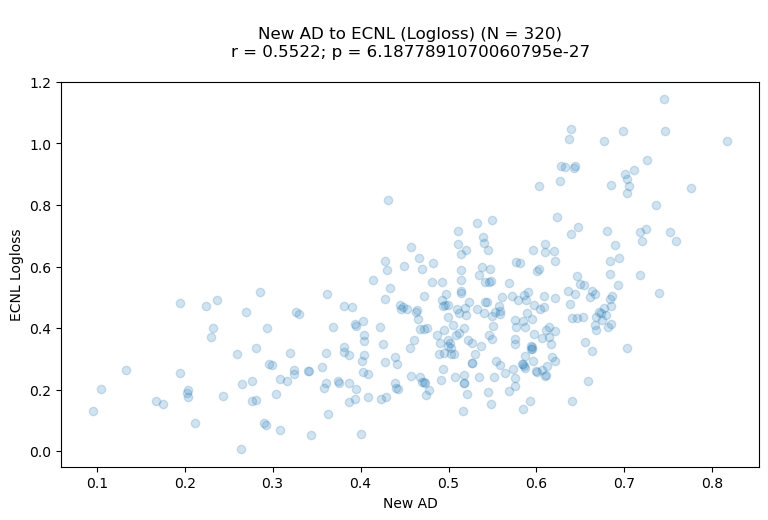

In [95]:
int_n = df_grouped.shape[0]
x = df_grouped['yhat_ad_new']
y = df_grouped['ecnl_new_logloss']
flt_r, flt_p = pearsonr(x, y)
str_title = f"""
New AD to ECNL (Logloss) (N = {int_n})
r = {flt_r:0.4f}; p = {flt_p}
"""
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(str_title)
ax.set_xlabel('New AD')
ax.set_ylabel('ECNL Logloss')
ax.scatter(x, y, alpha=0.2)
plt.show()

### Get approval rate by AD threshold (those approved by AD model using Gen XI tiers with factor)

100%|██████████| 1000/1000 [00:01<00:00, 912.67it/s]


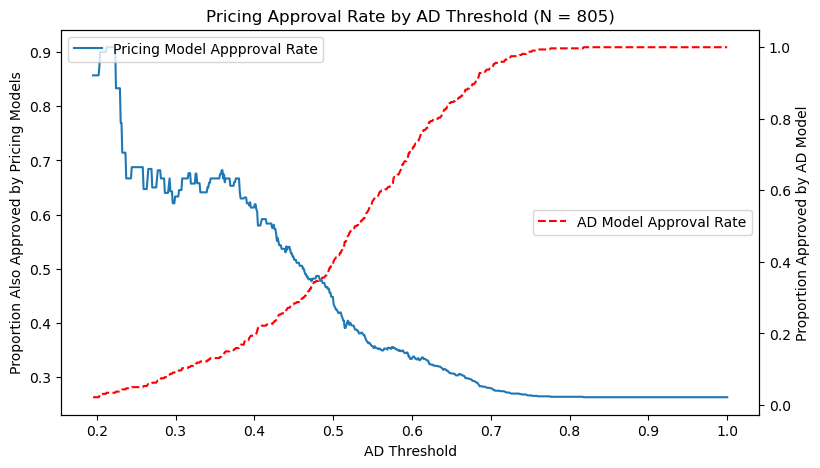

In [96]:
# get tier based off Gen XII score and Gen XI thresholds
df_grouped['tier_tmp'] = df_grouped['ecnl_new_logloss'].apply(
    lambda x: get_tier(
        flt_ecnl=x,
        dict_tiers=dict_tiers_factor,
    ),
)
list_flt_threshold = list(np.linspace(0, 1, 1000))
list_dict_row = []
for flt_threshold in tqdm(list_flt_threshold):
    # copy
    df_tmp = df_grouped.copy()
    int_n_all = df_tmp.shape[0]
    # subset
    df_tmp = df_tmp[df_tmp['yhat_ad_new'] <= flt_threshold].copy()
    int_n_approved_ad = df_tmp.shape[0]
    # get freq
    ser_freq = df_tmp['tier_tmp'].value_counts(normalize=True)
    try:
        flt_decline = ser_freq['Decline']
    except KeyError:
        continue
    flt_approval = 1 - flt_decline
    # dict row
    dict_row = {
        'threshold': flt_threshold,
        'approval_rate': flt_approval,
        'prop_approved_ad': int_n_approved_ad / int_n_all,
    }
    # append
    list_dict_row.append(dict_row)
# make df
df_tmp = pd.DataFrame(list_dict_row)

# drop
df_grouped.drop(['tier_tmp'], axis=1, inplace=True)

# plot
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(f'Pricing Approval Rate by AD Threshold (N = {df_tmp.shape[0]})')
ax.set_xlabel('AD Threshold')
ax.set_ylabel('Proportion Also Approved by Pricing Models')
ax.plot(df_tmp['threshold'], df_tmp['approval_rate'], label='Pricing Model Appproval Rate')
plt.legend(loc='upper left')
# second y label
ax2 = ax.twinx()
ax2.set_ylabel('Proportion Approved by AD Model')
ax2.plot(df_tmp['threshold'], df_tmp['prop_approved_ad'], linestyle='--', color='red', label='AD Model Approval Rate')
plt.legend(loc='center right')
plt.show()

### Get approval rate by AD threshold (those approved or declined by AD model using Gen XI tiers with factor)

100%|██████████| 1000/1000 [00:00<00:00, 1124.87it/s]


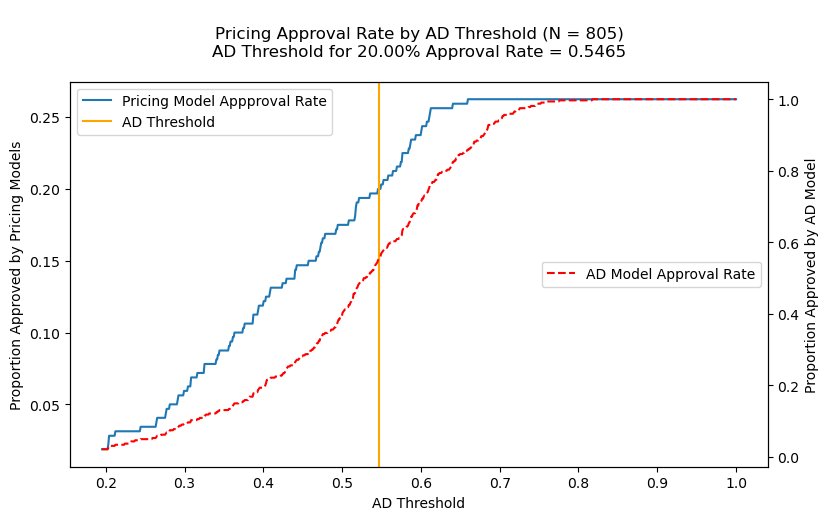

In [97]:
df_grouped['tier_tmp'] = df_grouped['ecnl_new_logloss'].apply(
    lambda x: get_tier(
        flt_ecnl=x,
        dict_tiers=dict_tiers_factor,
    ),
)
list_flt_threshold = list(np.linspace(0, 1, 1000))
list_dict_row = []
for flt_threshold in tqdm(list_flt_threshold):
    # copy
    df_tmp = df_grouped.copy()
    int_n_all = df_tmp.shape[0]
    
    # subset
    df_tmp = df_tmp[df_tmp['yhat_ad_new'] <= flt_threshold].copy()
    int_n_approved_ad = df_tmp.shape[0]
    flt_approval_ad = int_n_approved_ad / int_n_all
    
    # get freq
    ser_freq = df_tmp['tier_tmp'].value_counts(normalize=False)
    try:
        int_decline_pricing = ser_freq['Decline']
    except KeyError:
        continue
    int_approval_pricing = int_n_approved_ad - int_decline_pricing
    flt_approval_pricing = int_approval_pricing / int_n_all
        
    # dict row
    dict_row = {
        'threshold': flt_threshold,
        'approval_rate': flt_approval_pricing,
        'prop_approved_ad': flt_approval_ad,
    }
    # append
    list_dict_row.append(dict_row)
# make df
df_tmp = pd.DataFrame(list_dict_row)

# get AD threshold to target pricing approvaL rate
df_tmp['target'] = flt_target_approval_rate
df_tmp['diff'] = df_tmp['approval_rate'] - df_tmp['target']
df_tmp['diff'] = df_tmp['diff'].apply(abs)
df_tmp.sort_values(by='diff', ascending=True, inplace=True)
flt_ad_threshold = df_tmp['threshold'].iloc[0]

# re-sort
df_tmp.sort_values(by='threshold', ascending=True, inplace=True)

# drop
df_grouped.drop(['tier_tmp'], axis=1, inplace=True)

# plot
str_title = f"""
Pricing Approval Rate by AD Threshold (N = {df_tmp.shape[0]})
AD Threshold for {flt_target_approval_rate*100:0.2f}% Approval Rate = {flt_ad_threshold:0.4f}
"""
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(str_title)
ax.set_xlabel('AD Threshold')
ax.set_ylabel('Proportion Approved by Pricing Models')
ax.plot(df_tmp['threshold'], df_tmp['approval_rate'], label='Pricing Model Appproval Rate')
ax.axvline(flt_ad_threshold, color='orange', label='AD Threshold')
plt.legend(loc='upper left')
# second y label
ax2 = ax.twinx()
ax2.set_ylabel('Proportion Approved by AD Model')
ax2.plot(df_tmp['threshold'], df_tmp['prop_approved_ad'], linestyle='--', color='red', label='AD Model Approval Rate')
plt.legend(loc='center right')
plt.show()

### Approval rates by predetermined AD thresholds

100%|██████████| 10/10 [00:00<00:00, 975.92it/s]


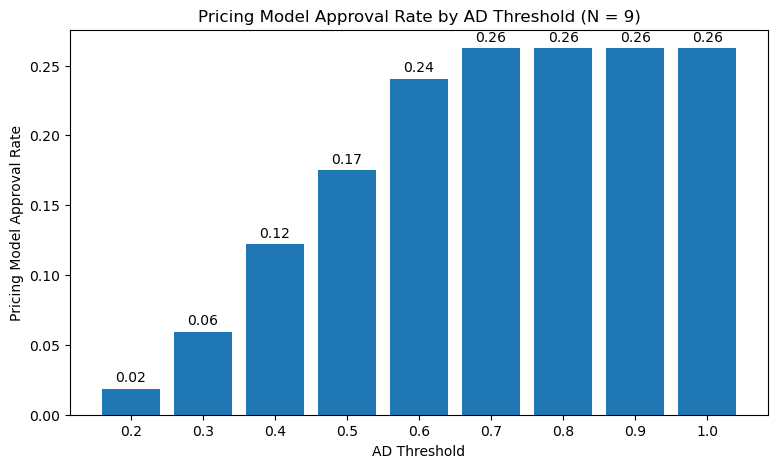

In [98]:
df_grouped['tier_tmp'] = df_grouped['ecnl_new_logloss'].apply(
    lambda x: get_tier(
        flt_ecnl=x,
        dict_tiers=dict_tiers_factor,
    ),
)

# thresholds
list_flt_threshold = [
    0.10,
    0.20,
    0.30,
    0.40,
    0.50,
    0.60,
    0.70,
    0.80,
    0.90,
    1.00,
]

list_dict_row = []
for flt_threshold in tqdm(list_flt_threshold):
    # copy
    df_tmp = df_grouped.copy()
    int_n_all = df_tmp.shape[0]
    
    # subset
    df_tmp = df_tmp[df_tmp['yhat_ad_new'] <= flt_threshold].copy()
    int_n_approved_ad = df_tmp.shape[0]
    flt_approval_ad = int_n_approved_ad / int_n_all
    
    # get freq
    ser_freq = df_tmp['tier_tmp'].value_counts(normalize=False)
    try:
        int_decline_pricing = ser_freq['Decline']
    except KeyError:
        continue
    int_approval_pricing = int_n_approved_ad - int_decline_pricing
    flt_approval_pricing = int_approval_pricing / int_n_all
        
    # dict row
    dict_row = {
        'threshold_ad': flt_threshold,
        'approval_rate_pricing': flt_approval_pricing,
        'approval_rate_ad': flt_approval_ad,
    }
    # append
    list_dict_row.append(dict_row)
# make df
df_tmp = pd.DataFrame(list_dict_row)

# drop
df_grouped.drop(['tier_tmp'], axis=1, inplace=True)

# plot
x = df_tmp['threshold_ad'].astype(str)
y = df_tmp['approval_rate_pricing']
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(f'Pricing Model Approval Rate by AD Threshold (N = {df_tmp.shape[0]})')
ax.set_xlabel('AD Threshold')
ax.set_ylabel('Pricing Model Approval Rate')
bars = ax.bar(x, y)
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:0.2f}',
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 3),  # 3 points vertical offset
        textcoords="offset points",
        ha='center',
        va='bottom',
    )
# show
plt.show()

### Get mean ECNL by AD threshold

100%|██████████| 1000/1000 [00:00<00:00, 1673.50it/s]


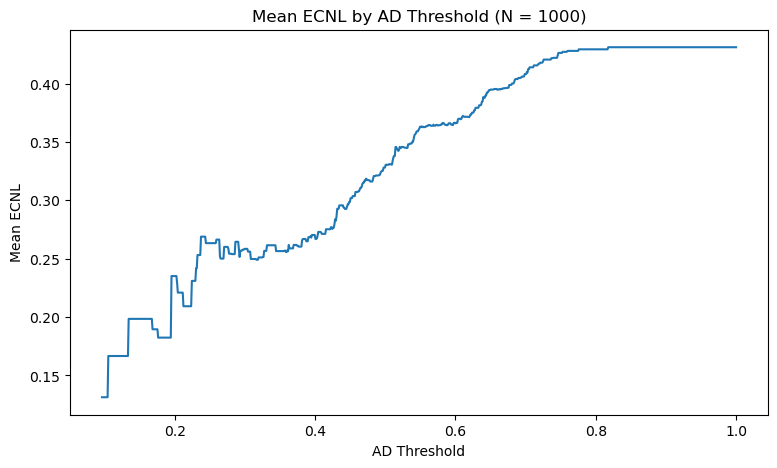

In [99]:
list_flt_threshold = list(np.linspace(0, 1, 1000))

list_dict_row = []
for flt_threshold in tqdm(list_flt_threshold):
    # copy
    df_tmp = df_grouped.copy()
    
    # subset
    df_tmp = df_tmp[df_tmp['yhat_ad_new'] <= flt_threshold].copy()
    
    # get mean ecnl
    flt_mean = df_tmp['ecnl_new_logloss'].mean()
            
    # dict row
    dict_row = {
        'threshold_ad': flt_threshold,
        'mean_ecnl': flt_mean,
    }
    # append
    list_dict_row.append(dict_row)
# make df
df_tmp = pd.DataFrame(list_dict_row)

# plot
x = df_tmp['threshold_ad']
y = df_tmp['mean_ecnl']
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(f'Mean ECNL by AD Threshold (N = {df_tmp.shape[0]})')
ax.set_xlabel('AD Threshold')
ax.set_ylabel('Mean ECNL')
ax.plot(x, y)
# show
plt.show()

### Get mean ECNL by predetermined AD thresholds

100%|██████████| 10/10 [00:00<00:00, 1366.00it/s]


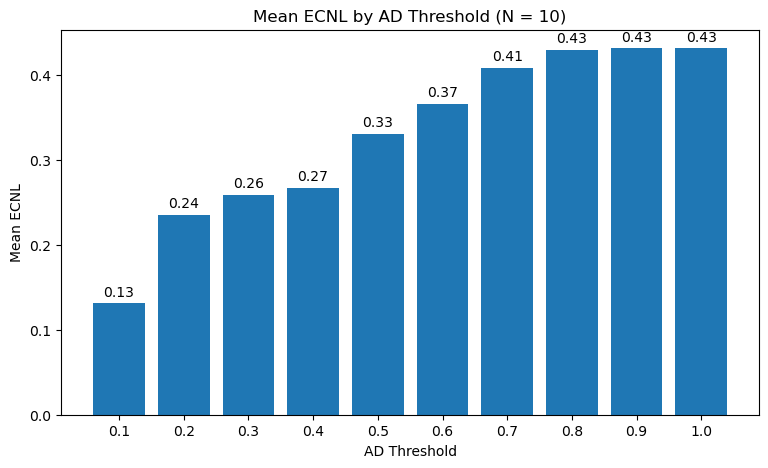

In [100]:
# thresholds
list_flt_threshold = [
    0.10,
    0.20,
    0.30,
    0.40,
    0.50,
    0.60,
    0.70,
    0.80,
    0.90,
    1.00,
]

list_dict_row = []
for flt_threshold in tqdm(list_flt_threshold):
    # copy
    df_tmp = df_grouped.copy()
    
    # subset
    df_tmp = df_tmp[df_tmp['yhat_ad_new'] <= flt_threshold].copy()
    
    # get mean ecnl
    flt_mean = df_tmp['ecnl_new_logloss'].mean()
            
    # dict row
    dict_row = {
        'threshold_ad': flt_threshold,
        'mean_ecnl': flt_mean,
    }
    # append
    list_dict_row.append(dict_row)
# make df
df_tmp = pd.DataFrame(list_dict_row)

# plot
x = df_tmp['threshold_ad'].astype(str)
y = df_tmp['mean_ecnl']
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(f'Mean ECNL by AD Threshold (N = {df_tmp.shape[0]})')
ax.set_xlabel('AD Threshold')
ax.set_ylabel('Mean ECNL')
bars = ax.bar(x, y)
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:0.2f}',
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 3),  # 3 points vertical offset
        textcoords="offset points",
        ha='center',
        va='bottom',
    )
# show
plt.show()

### AD

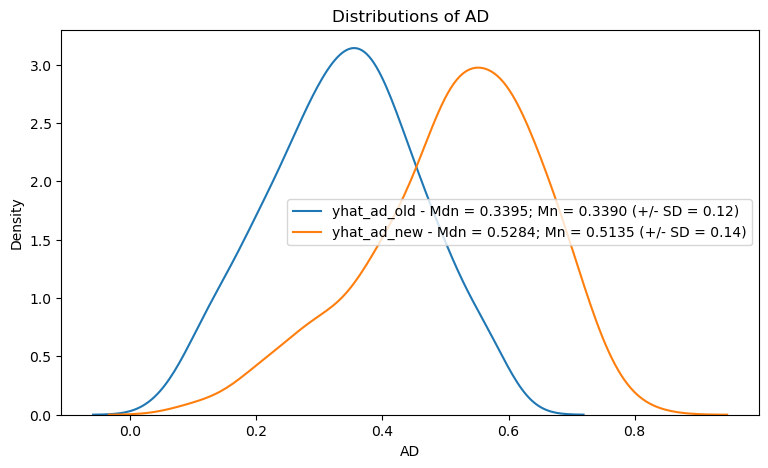

In [101]:
str_title = 'Distributions of AD'
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(str_title)
ax.set_xlabel('AD')
for str_ad in list_str_ad:
    # plot
    list_values = list(df_grouped[str_ad])
    flt_mdn = np.median(list_values)
    flt_mean = np.mean(list_values)
    flt_sd = np.std(list_values)
    str_label = f'{str_ad} - Mdn = {flt_mdn:0.4f}; Mn = {flt_mean:0.4f} (+/- SD = {flt_sd:0.2f})'
    sns.kdeplot(list_values, ax=ax, label=str_label)
plt.legend()
plt.show()

### PD

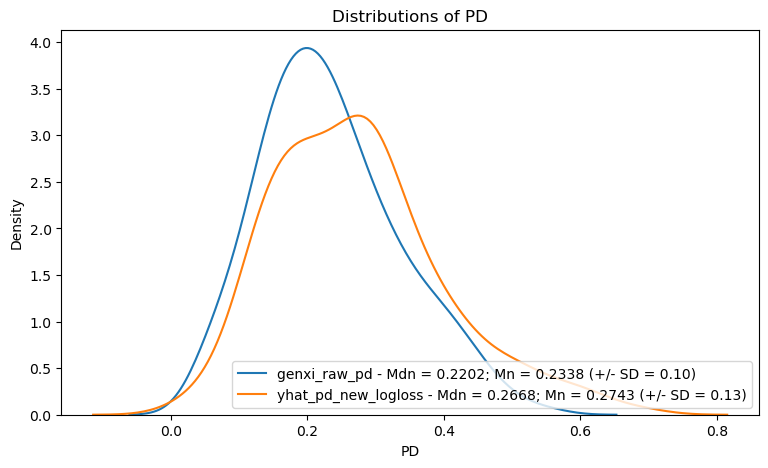

In [102]:
str_title = 'Distributions of PD'
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(str_title)
ax.set_xlabel('PD')
for str_pd in list_str_pd:
    # plot
    list_values = list(df_grouped[str_pd])
    flt_mdn = np.median(list_values)
    flt_mean = np.mean(list_values)
    flt_sd = np.std(list_values)
    str_label = f'{str_pd} - Mdn = {flt_mdn:0.4f}; Mn = {flt_mean:0.4f} (+/- SD = {flt_sd:0.2f})'
    sns.kdeplot(list_values, ax=ax, label=str_label)
plt.legend(loc='lower right')
plt.show()

### LGD

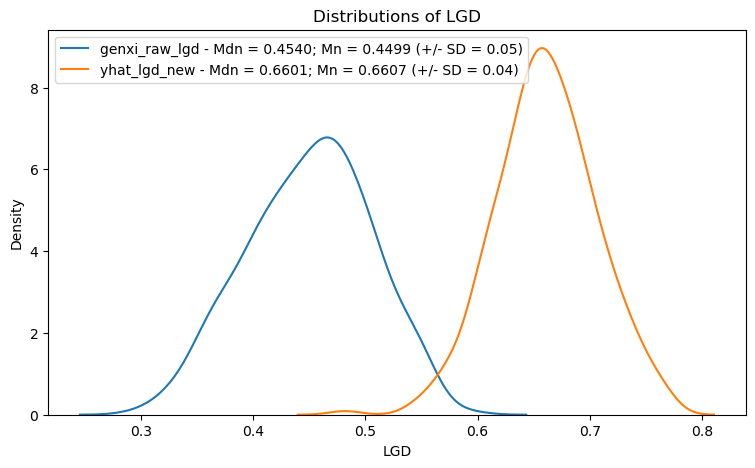

In [103]:
str_title = 'Distributions of LGD'
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(str_title)
ax.set_xlabel('LGD')
for str_lgd in list_str_lgd:
    # plot
    list_values = list(df_grouped[str_lgd])
    flt_mdn = np.median(list_values)
    flt_mean = np.mean(list_values)
    flt_sd = np.std(list_values)
    str_label = f'{str_lgd} - Mdn = {flt_mdn:0.4f}; Mn = {flt_mean:0.4f} (+/- SD = {flt_sd:0.2f})'
    sns.kdeplot(list_values, ax=ax, label=str_label)
plt.legend(loc='upper left')
plt.show()

### ECNL

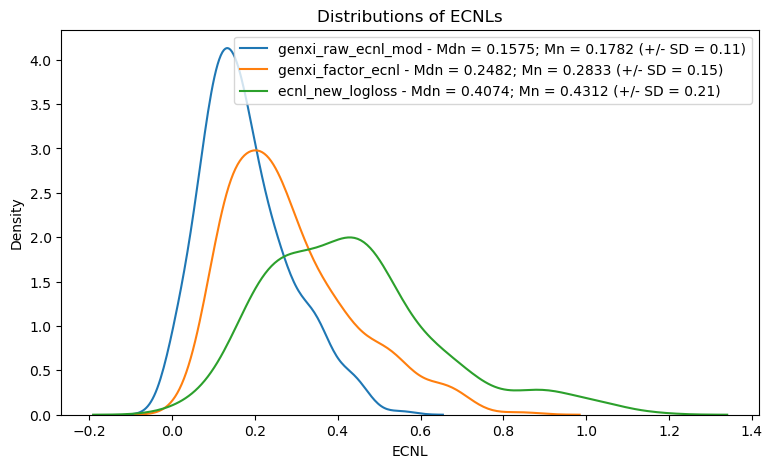

In [104]:
str_title = 'Distributions of ECNLs'
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(str_title)
ax.set_xlabel('ECNL')
for str_ecnl in list_str_ecnl:
    # plot
    list_values = list(df_grouped[str_ecnl])
    flt_mdn = np.median(list_values)
    flt_mean = np.mean(list_values)
    flt_sd = np.std(list_values)
    str_label = f'{str_ecnl} - Mdn = {flt_mdn:0.4f}; Mn = {flt_mean:0.4f} (+/- SD = {flt_sd:0.2f})'
    sns.kdeplot(list_values, ax=ax, label=str_label)
plt.legend()
plt.show()

### Gen XI with factors by BK type with Gen XII by BK type

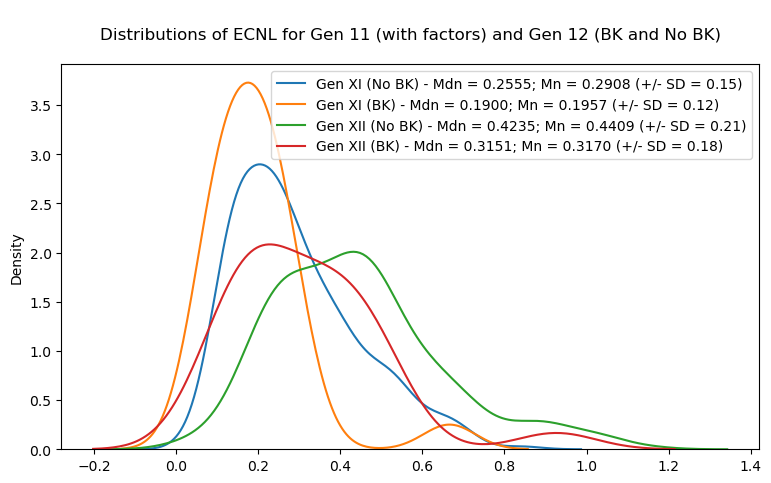

In [105]:
fig, ax = plt.subplots(figsize=(9,5))
str_title = """
Distributions of ECNL for Gen 11 (with factors) and Gen 12 (BK and No BK)
"""
ax.set_title(str_title)
# gen xi with factors - no bk
list_tmp =  list(df_grouped[df_grouped['intopenbktype__app'] == 'nan'].copy()['genxi_factor_ecnl'])
flt_mean, flt_sd, flt_mdn = np.mean(list_tmp), np.std(list_tmp), np.median(list_tmp)
str_label = f'Gen XI (No BK) - Mdn = {flt_mdn:0.4f}; Mn = {flt_mean:0.4f} (+/- SD = {flt_sd:0.2f})'
sns.kdeplot(list_tmp, label=str_label, ax=ax)
# gen xi with factors - bk
list_tmp =  list(df_grouped[df_grouped['intopenbktype__app'] != 'nan'].copy()['genxi_factor_ecnl'])
flt_mean, flt_sd, flt_mdn = np.mean(list_tmp), np.std(list_tmp), np.median(list_tmp)
str_label = f'Gen XI (BK) - Mdn = {flt_mdn:0.4f}; Mn = {flt_mean:0.4f} (+/- SD = {flt_sd:0.2f})'
sns.kdeplot(list_tmp, label=str_label, ax=ax)
# gen xii - no bk
list_tmp =  list(df_grouped[df_grouped['intopenbktype__app'] == 'nan'].copy()['ecnl_new_logloss'])
flt_mean, flt_sd, flt_mdn = np.mean(list_tmp), np.std(list_tmp), np.median(list_tmp)
str_label = f'Gen XII (No BK) - Mdn = {flt_mdn:0.4f}; Mn = {flt_mean:0.4f} (+/- SD = {flt_sd:0.2f})'
sns.kdeplot(list_tmp, label=str_label, ax=ax)
# gen xii - bk
list_tmp =  list(df_grouped[df_grouped['intopenbktype__app'] != 'nan'].copy()['ecnl_new_logloss'])
flt_mean, flt_sd, flt_mdn = np.mean(list_tmp), np.std(list_tmp), np.median(list_tmp)
str_label = f'Gen XII (BK) - Mdn = {flt_mdn:0.4f}; Mn = {flt_mean:0.4f} (+/- SD = {flt_sd:0.2f})'
sns.kdeplot(list_tmp, label=str_label, ax=ax)

# legend
plt.legend()
# show
plt.show()

### Average difference between Gen XI and Gen XII by BK Type

In [106]:
list_list_bk_type = [
    ['nan','7.0','13.0'],
    ['nan'],
    ['7.0','13.0'],
]
for list_bk_type in list_list_bk_type:
    # gen 11 vs gen 12
    list_cols = [
        'intopenbktype__app',
        'genxi_factor_ecnl',
        'ecnl_new_logloss',
    ]
    df_tmp = df_grouped[list_cols].copy()
    df_tmp = df_tmp[df_tmp['intopenbktype__app'].isin(list_bk_type)].copy()
    df_tmp['diff'] = df_tmp['ecnl_new_logloss'] - df_tmp['genxi_factor_ecnl']
    flt_mean = df_tmp['diff'].mean()
    print(f'Average difference between Gen XI and Gen XII ({list_bk_type}): {flt_mean:0.4f} (N = {df_tmp.shape[0]})')

Average difference between Gen XI and Gen XII (['nan', '7.0', '13.0']): 0.1479 (N = 320)
Average difference between Gen XI and Gen XII (['nan']): 0.1502 (N = 295)
Average difference between Gen XI and Gen XII (['7.0', '13.0']): 0.1213 (N = 25)


### Average difference between Gen XI (with factors) and Gen XII by Gen XI Tier (with factors)

In [107]:
list_str_tier = [
    'A1',
    'A',
    'B',
    'C',
    'D',
    'Decline',
]
for str_tier in list_str_tier:
    # gen 11 vs gen 12 - A1
    list_cols = [
        'tier',
        'genxi_factor_ecnl',
        'ecnl_new_logloss',
    ]
    df_tmp = df_grouped[list_cols].copy()
    # get factored tier
    df_tmp['tier_factor'] = df_tmp['genxi_factor_ecnl'].apply(
        lambda x: get_tier(
            flt_ecnl=x,
            dict_tiers=dict_tiers_factor,
        ),
    )
    # subset
    df_tmp = df_tmp[df_tmp['tier'] == str_tier].copy()
    df_tmp['diff'] = df_tmp['ecnl_new_logloss'] - df_tmp['genxi_factor_ecnl']
    flt_mean = df_tmp['diff'].mean()
    print(f'Average difference between Gen XI ({str_tier}) and Gen XII: {flt_mean:0.4f} (N = {df_tmp.shape[0]})')

Average difference between Gen XI (A1) and Gen XII: 0.0932 (N = 3)
Average difference between Gen XI (A) and Gen XII: 0.1153 (N = 12)
Average difference between Gen XI (B) and Gen XII: 0.1797 (N = 103)
Average difference between Gen XI (C) and Gen XII: 0.1986 (N = 53)
Average difference between Gen XI (D) and Gen XII: 0.1422 (N = 19)
Average difference between Gen XI (Decline) and Gen XII: 0.1071 (N = 130)


### Relation between Gen 11 and Gen 12

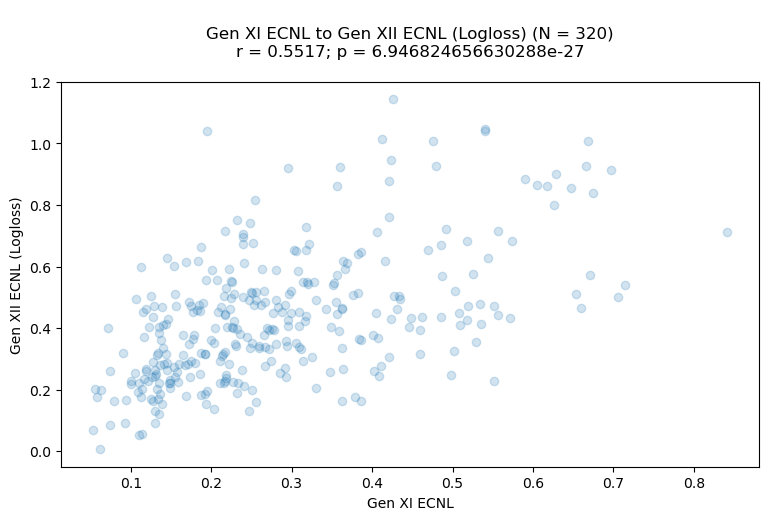

In [108]:
int_n = df_grouped.shape[0]
x = df_grouped['genxi_factor_ecnl']
y = df_grouped['ecnl_new_logloss']
flt_r, flt_p = pearsonr(x, y)
str_title = f"""
Gen XI ECNL to Gen XII ECNL (Logloss) (N = {int_n})
r = {flt_r:0.4f}; p = {flt_p}
"""
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(str_title)
ax.set_xlabel('Gen XI ECNL')
ax.set_ylabel('Gen XII ECNL (Logloss)')
ax.scatter(x, y, alpha=0.2)
plt.show()

### Plots for each column

In [109]:
list_str_col = [
    # AD
    #'yhat_ad_old',
    'yhat_ad_new',
    # PD
    #'genxi_raw_pd',
    #'genxi_factor_pd',
    #'yhat_pd_old',
    'yhat_pd_new_logloss',
    #'yhat_pd_new_auc',
    # LGD
    #'genxi_raw_lgd',
    #'genxi_factor_lgd',
    #'yhat_lgd_old',
    'yhat_lgd_new',
    # ECNL
    'genxi_raw_ecnl_mod',
    'genxi_factor_ecnl',
    #'ecnl_old',
    'ecnl_new_logloss',
    #'ecnl_new_auc',
]

### BK Type

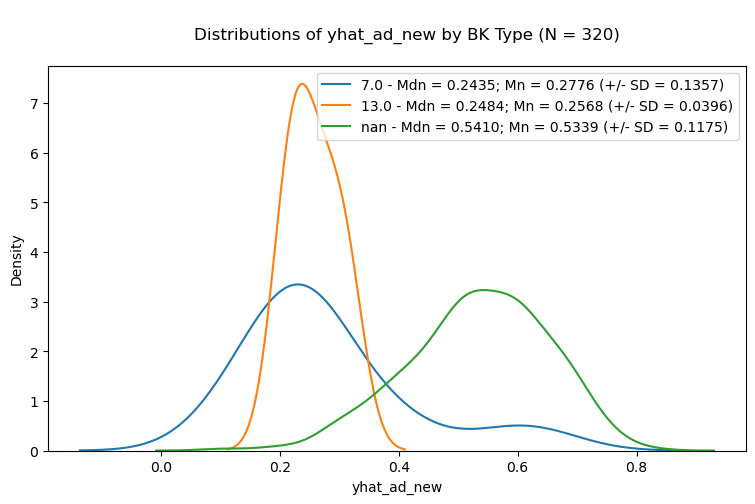

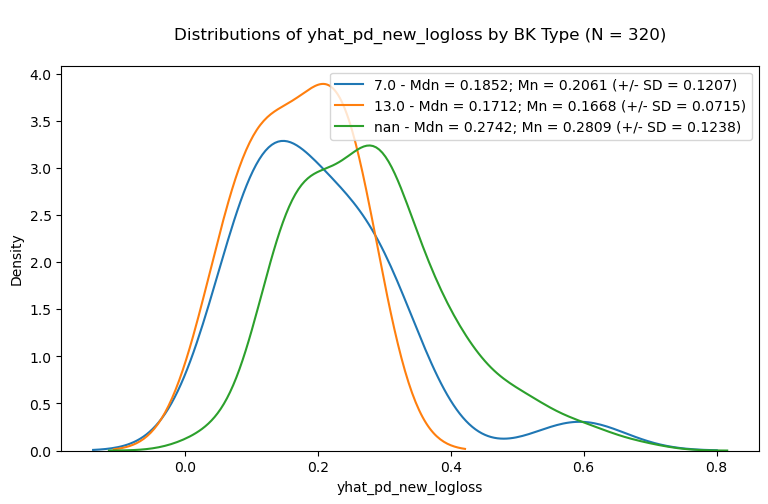

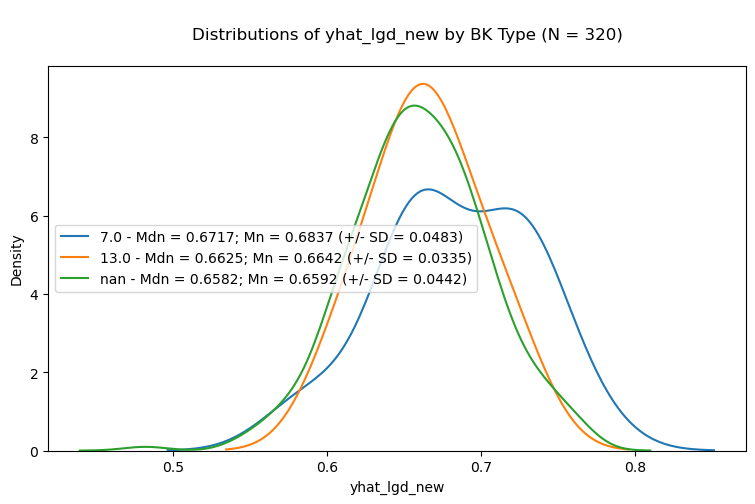

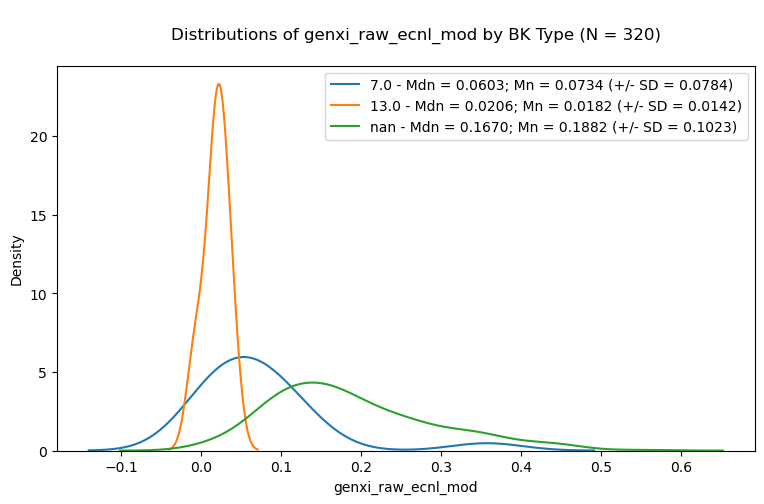

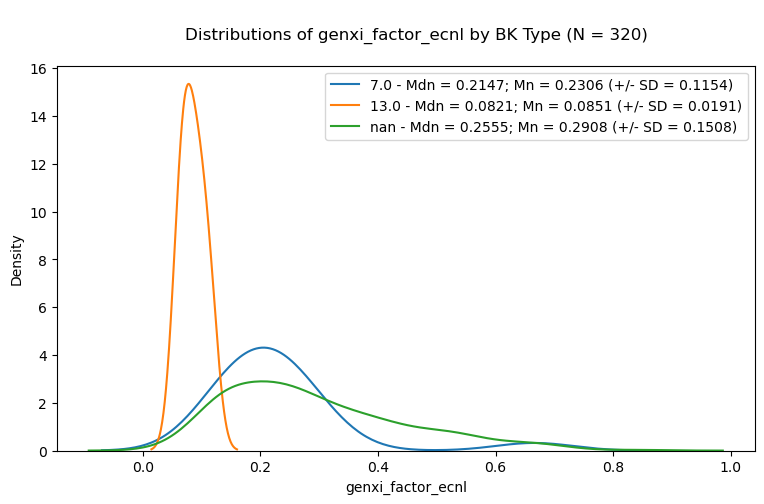

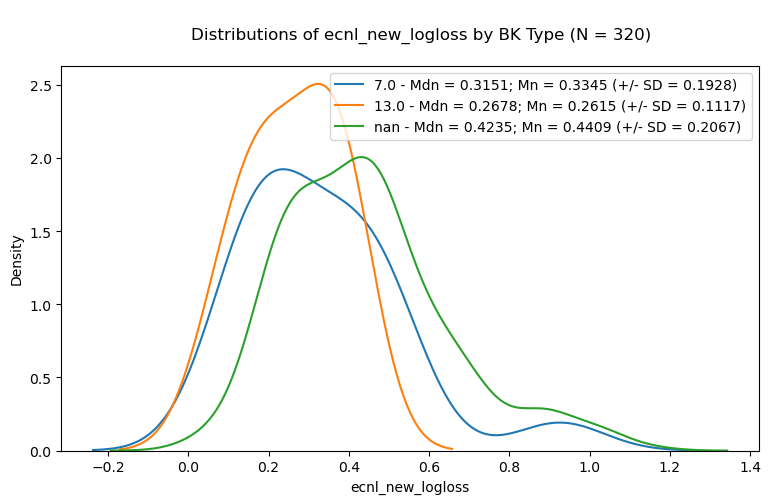

In [110]:
for str_col in list_str_col:
    plot_distributions_by_bktype(
        df_grouped=df_grouped, 
        str_col=str_col,
    )

### Dealer type

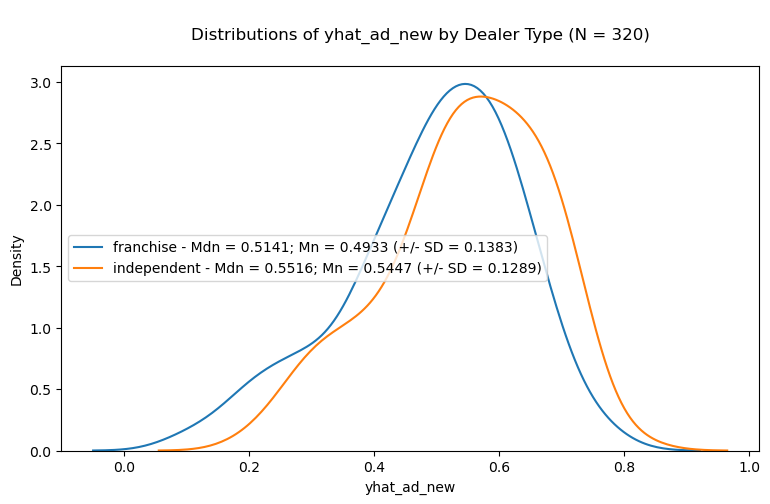

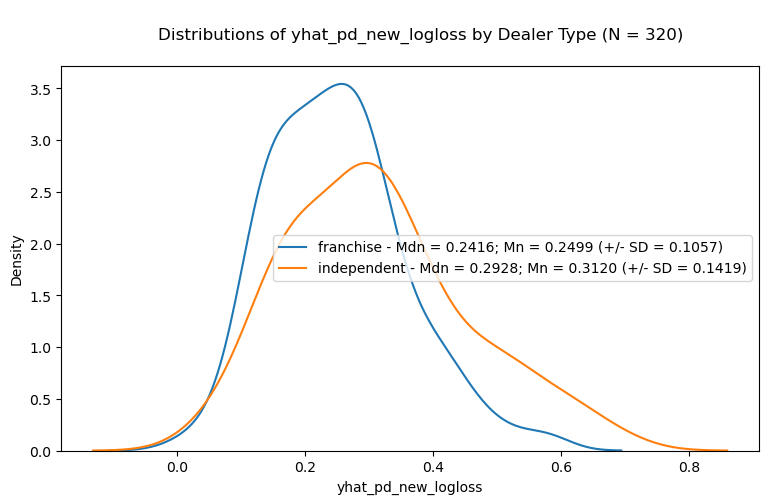

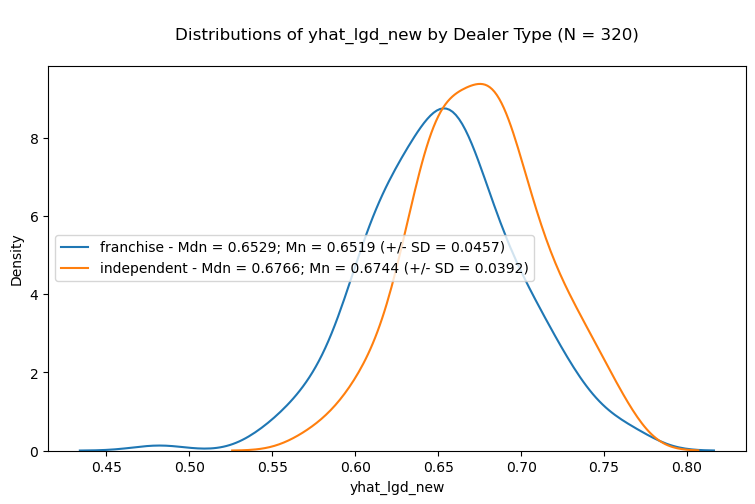

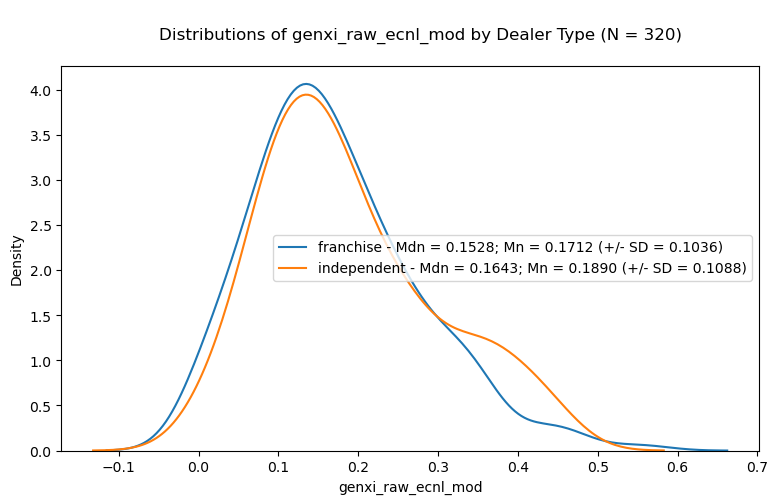

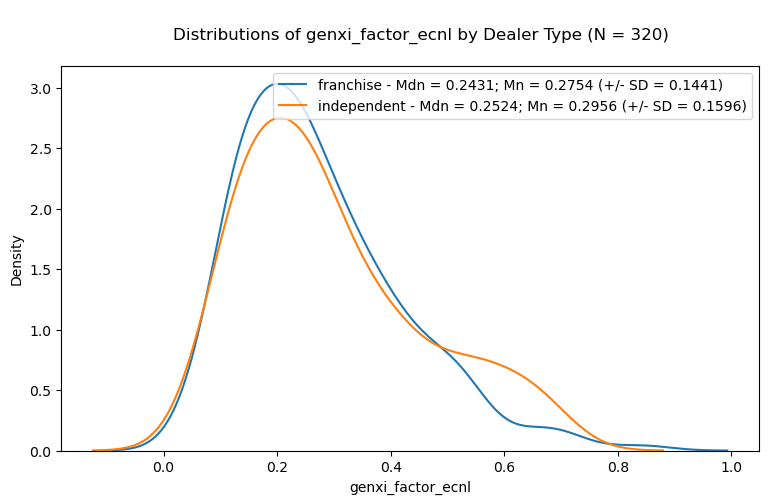

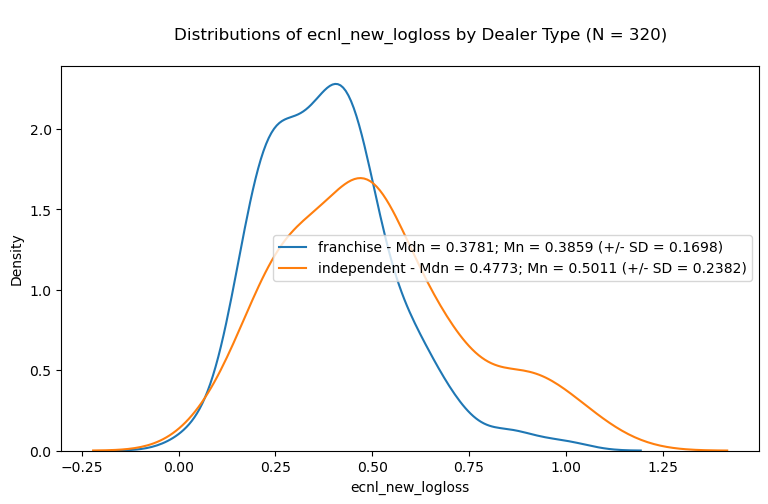

In [111]:
for str_col in list_str_col:
    plot_distributions_by_dealertype(
        df_grouped=df_grouped, 
        str_col=str_col,
    )

### LTV

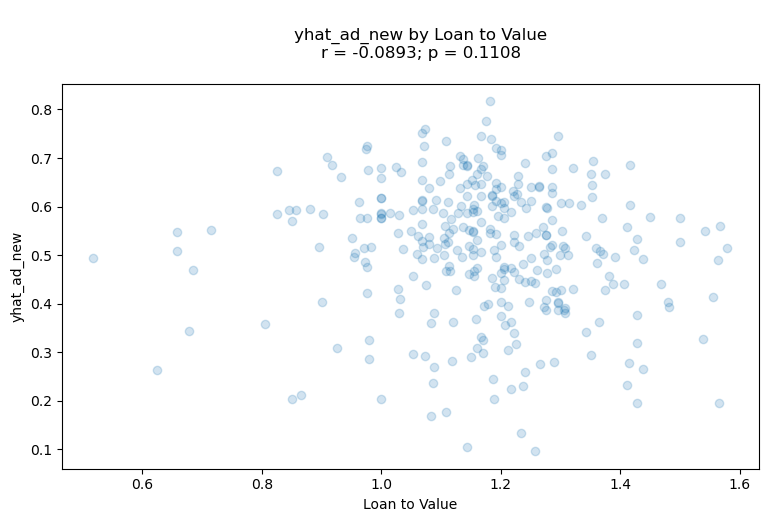

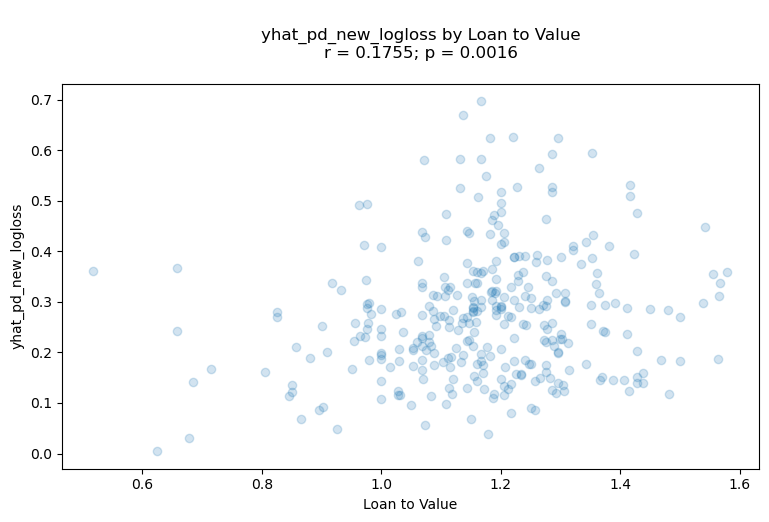

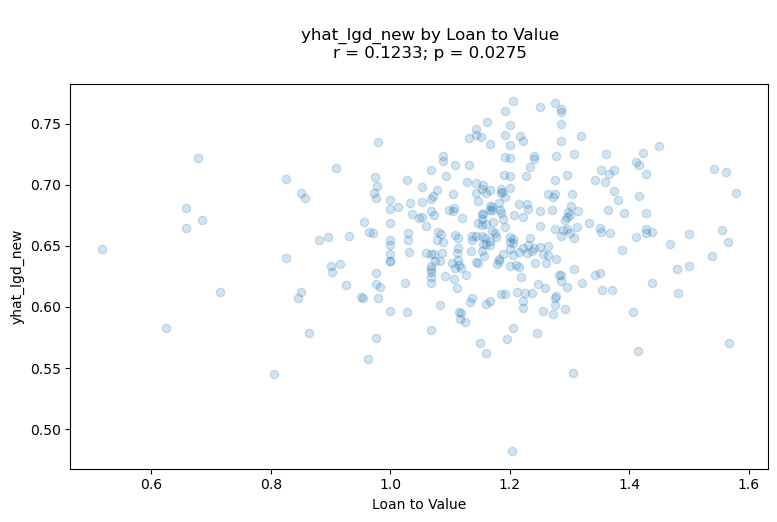

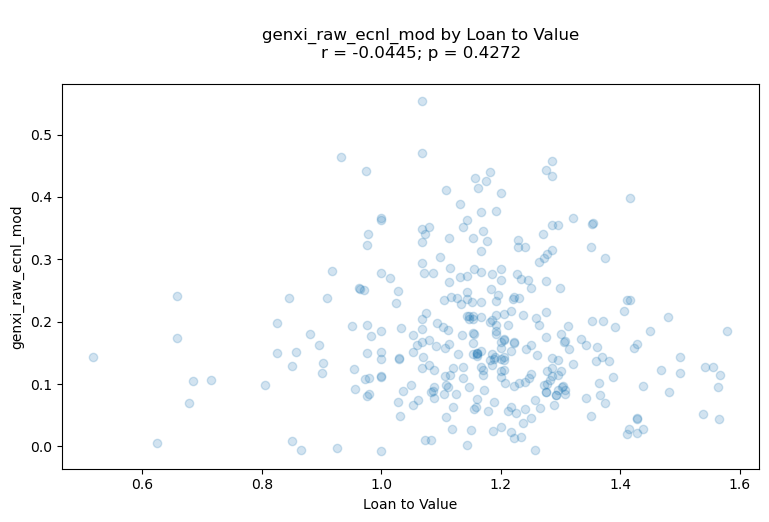

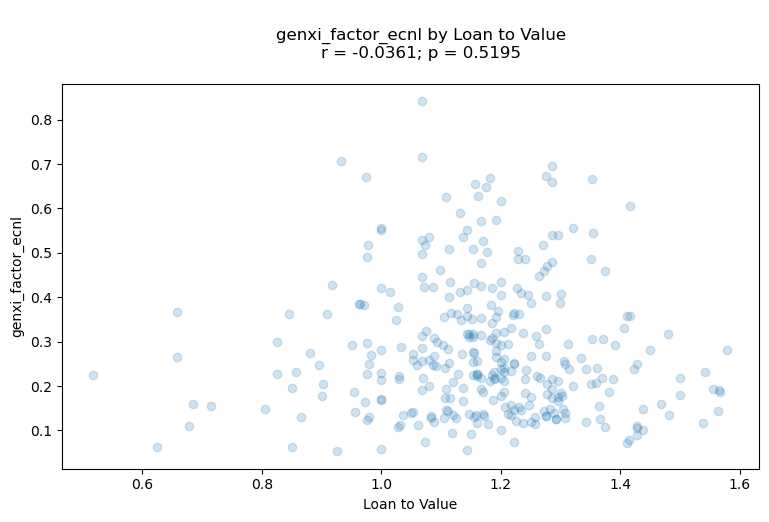

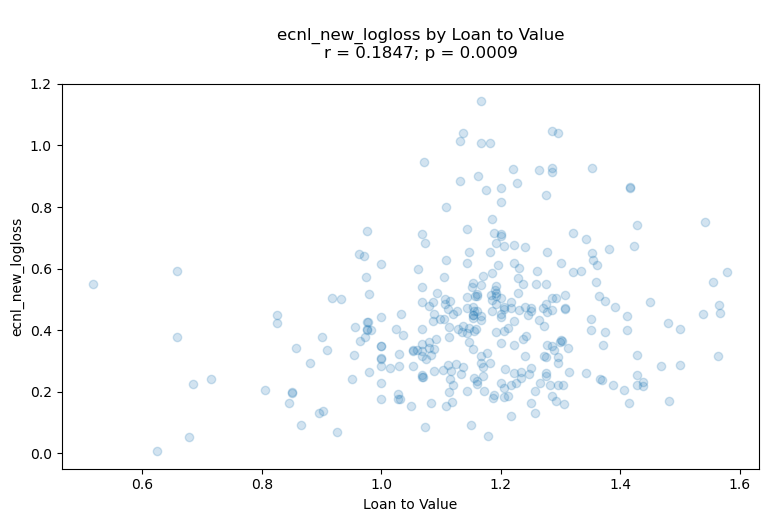

In [112]:
for str_col in list_str_col:
    correlation_with_ltv(
        df_grouped=df_grouped, 
        str_col=str_col,
    )

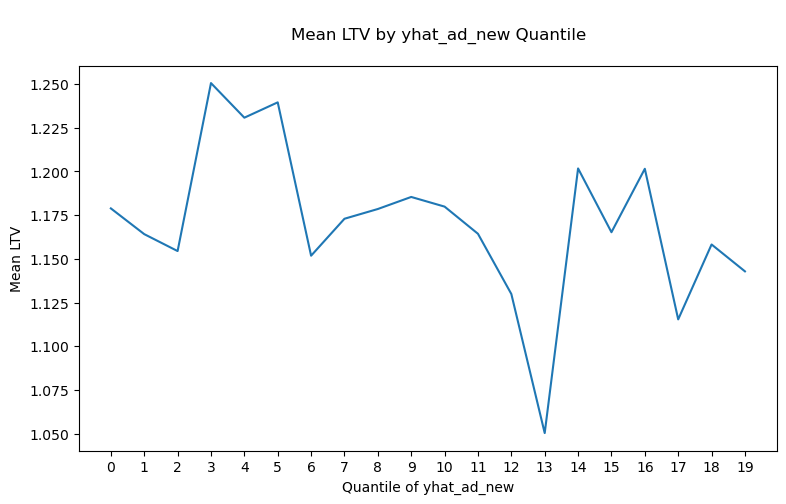

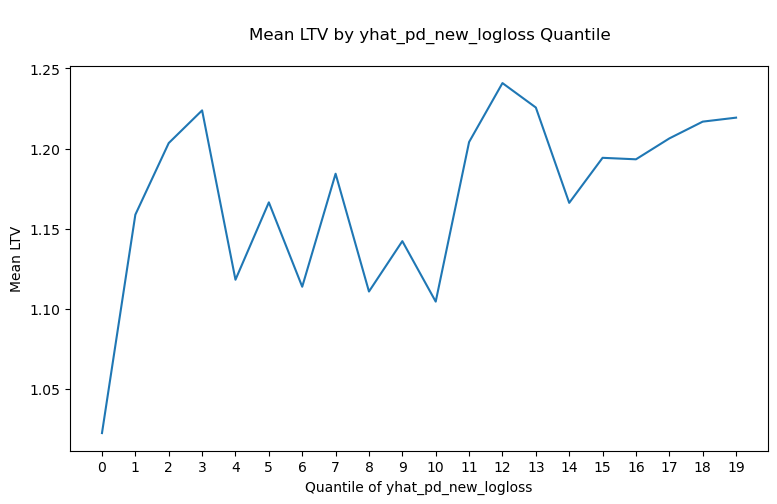

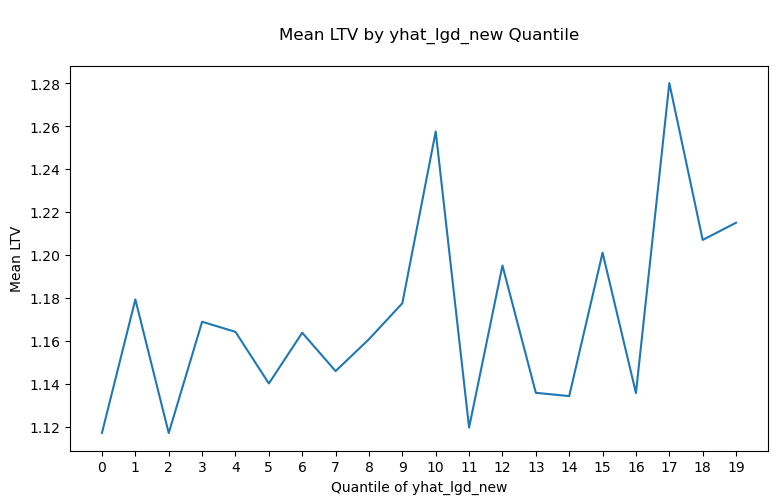

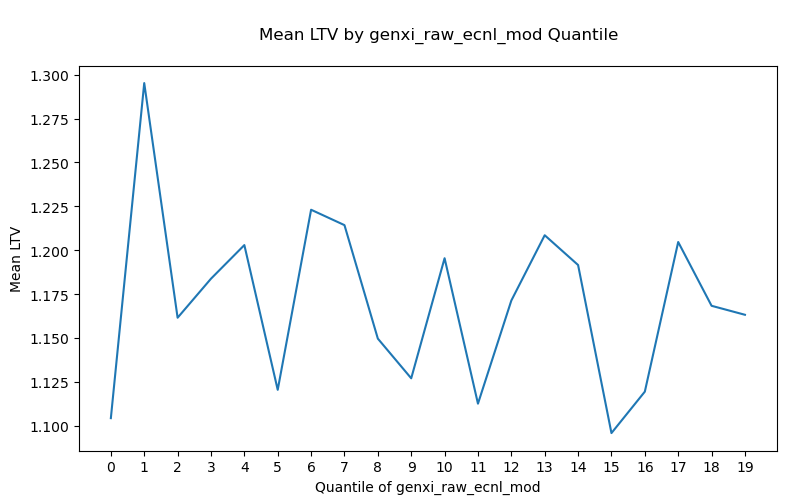

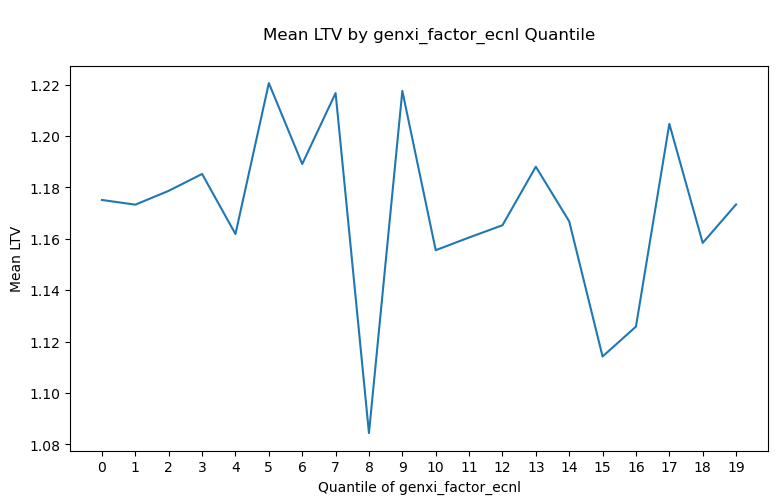

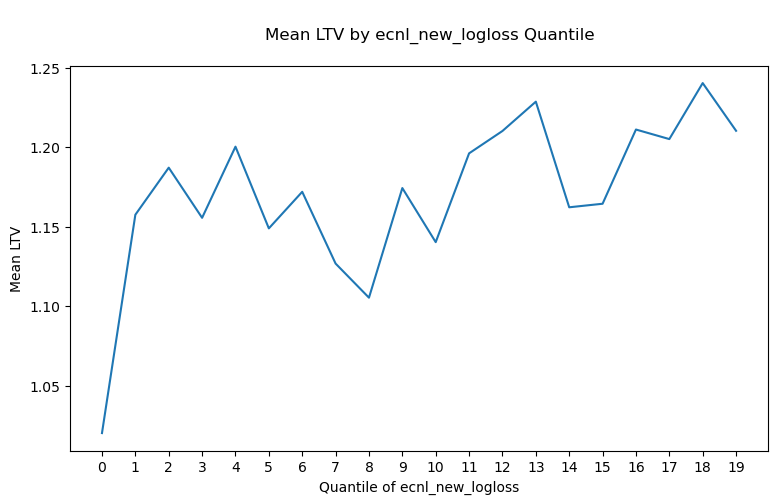

In [113]:
for str_col in list_str_col:
    try:
        mean_ltv_by_quantile(
            df_grouped=df_grouped, 
            str_col=str_col,
        )
    except ValueError:
        pass

### Income

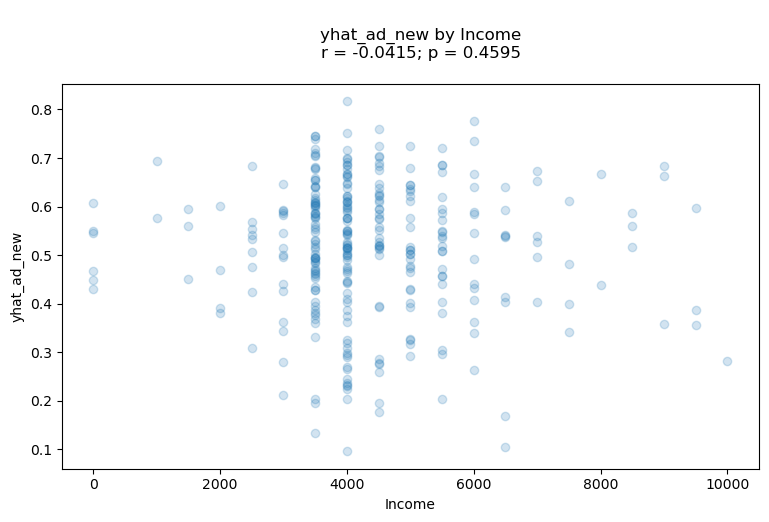

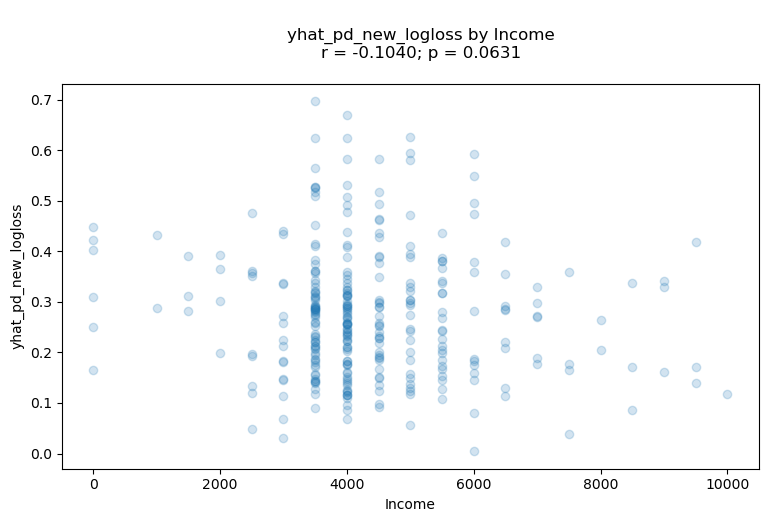

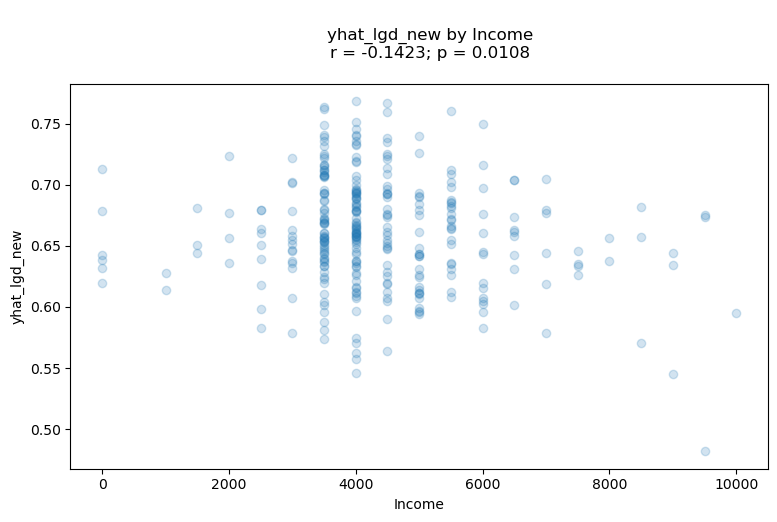

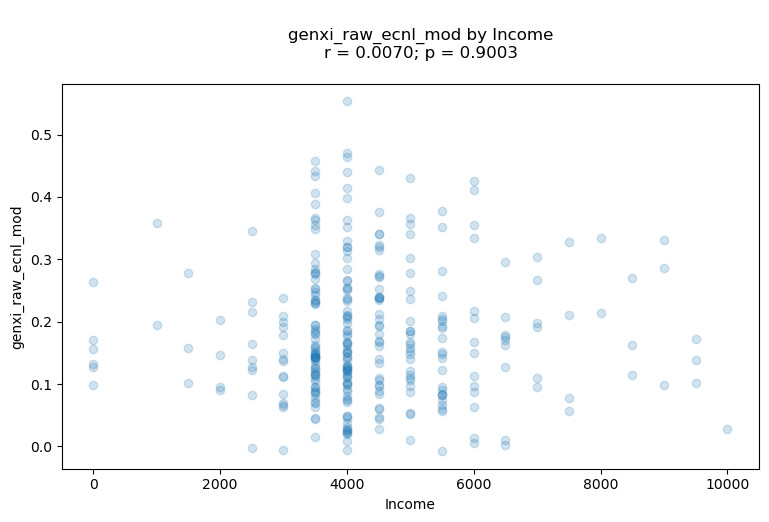

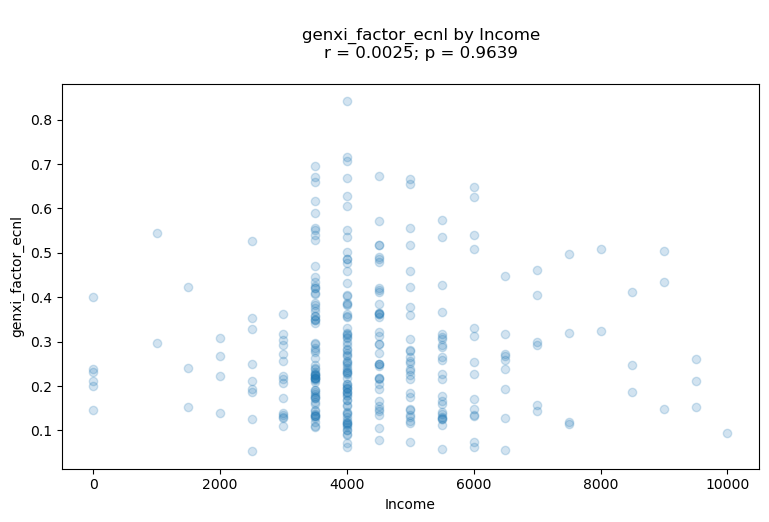

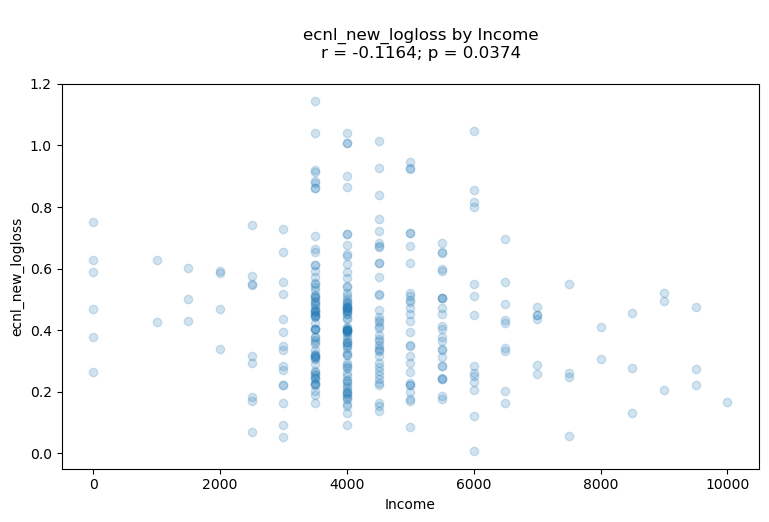

In [114]:
for str_col in list_str_col:
    correlation_with_income(
        df_grouped=df_grouped, 
        str_col=str_col,
    )

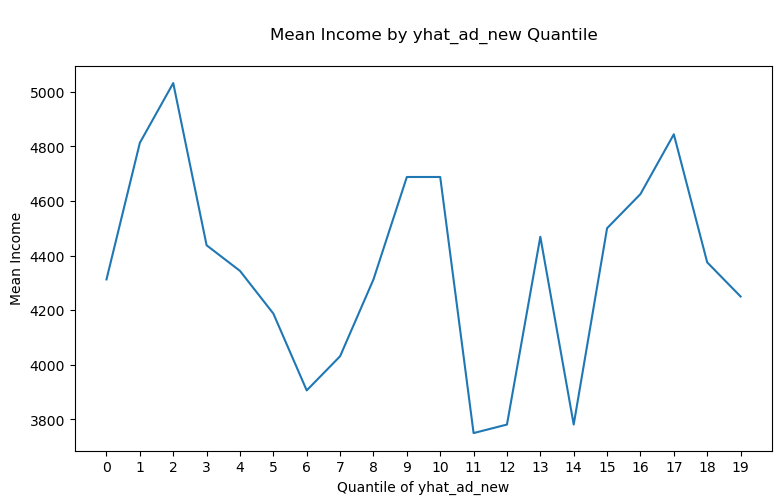

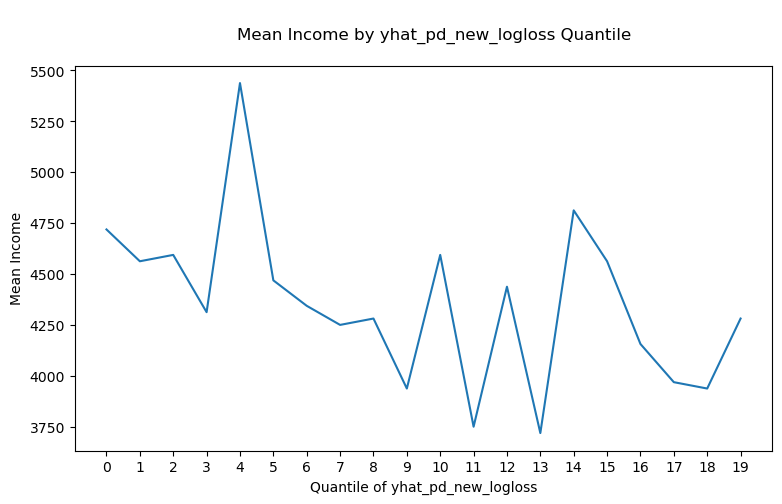

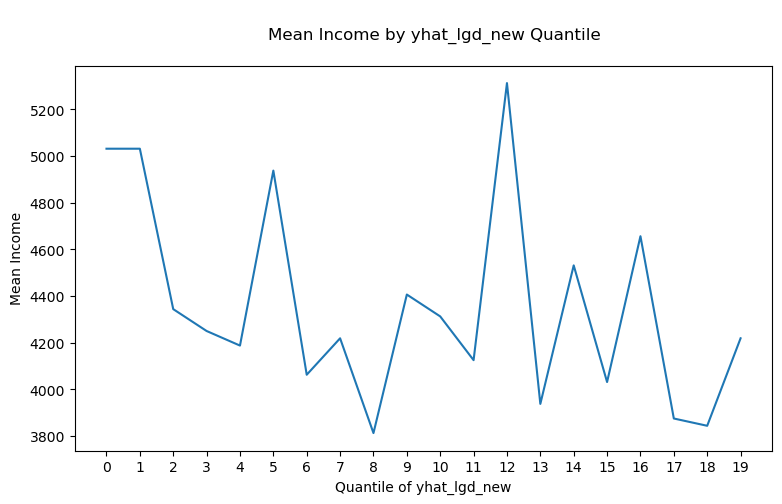

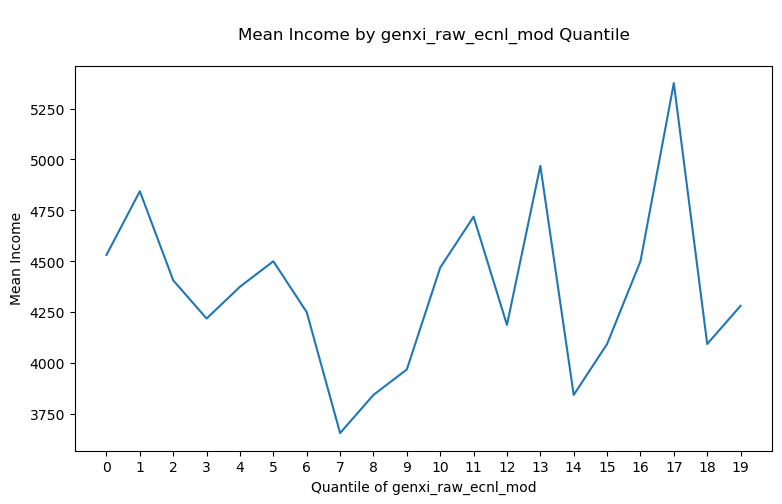

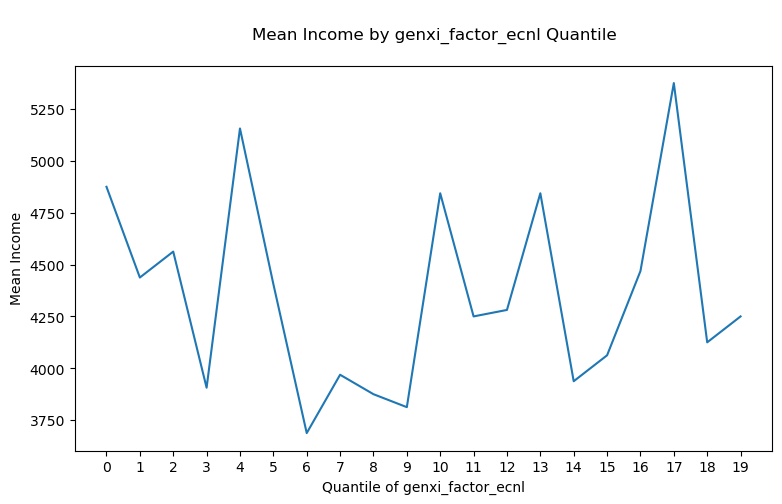

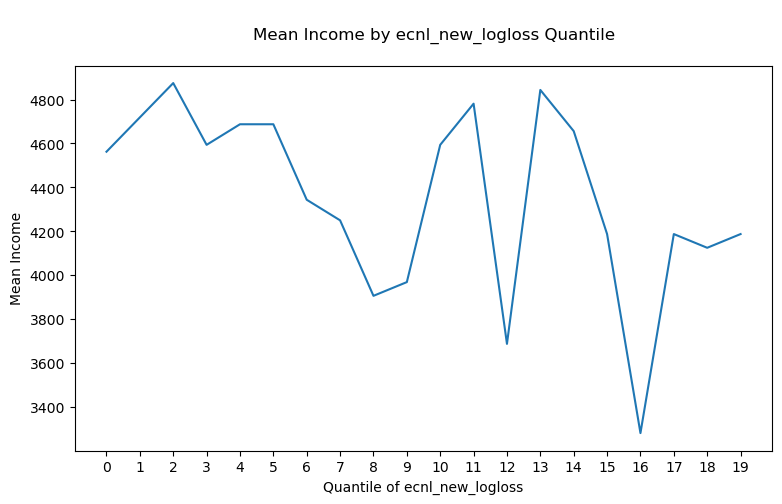

In [115]:
for str_col in list_str_col:
    try:
        mean_income_by_quantile(
            df_grouped=df_grouped, 
            str_col=str_col,
        )
    except ValueError:
        pass

### Clean-up

In [116]:
list_str_filename = [
    'cls_model_preprocessing.pkl',
    'preprocessing.py',
]
for str_filename in list_str_filename:
    try:
        os.remove(str_filename)
    except:
        pass